In [1]:
# ============================================================
# Cell 1: Imports & Environment Sanity Check
# (RF-DETR detection + ByteTrack tracking)
# ============================================================

# ---- Standard library ----
import os
import sys
import time
import json
import random
from pathlib import Path
from typing import List, Dict, Tuple, Optional

# ---- Numerical / scientific ----
import numpy as np

# ---- Computer vision / video I/O ----
import cv2

# ---- Visualization ----
import matplotlib.pyplot as plt

# ---- Deep learning ----
import torch

# ---- Detector ----
from rfdetr import RFDETRNano

# ---- Tracking (ByteTrack) ----
# supervision provides a ByteTrack wrapper that's convenient for notebooks
try:
    import supervision as sv
    SUPERVISION_OK = True
except Exception as e:
    SUPERVISION_OK = False
    print("Could not import supervision (needed for ByteTrack).")
    print(" Install with: pip install supervision")
    print(" Import error:", repr(e))

# ---- Utilities ----
from tqdm.auto import tqdm
import psutil

# ============================================================
# Environment sanity prints
# ============================================================

print("=== Environment Check ===")
print(f"Python version      : {sys.version.split()[0]}")
print(f"PyTorch version     : {torch.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version        : {torch.version.cuda}")
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")

print(f"CPU cores           : {psutil.cpu_count(logical=True)}")
print(f"supervision ready   : {SUPERVISION_OK}")
if SUPERVISION_OK:
    print(f"supervision version : {sv.__version__}")
print("=========================")

=== Environment Check ===
Python version      : 3.11.9
PyTorch version     : 2.5.1+cu121
CUDA available      : False
CPU cores           : 8
supervision ready   : True
supervision version : 0.27.0


Device: cpu
Checkpoint: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\models\enhanced-training\visdrone_rfdetr_nano_best_ema.pth
Loading detector from checkpoint...
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Detector loaded and ready.
Sanity test image: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\visdrone-dataset-rgb\val\images\0000312_00601_d_0000417.jpg


Detections: 36 (threshold=0.3)


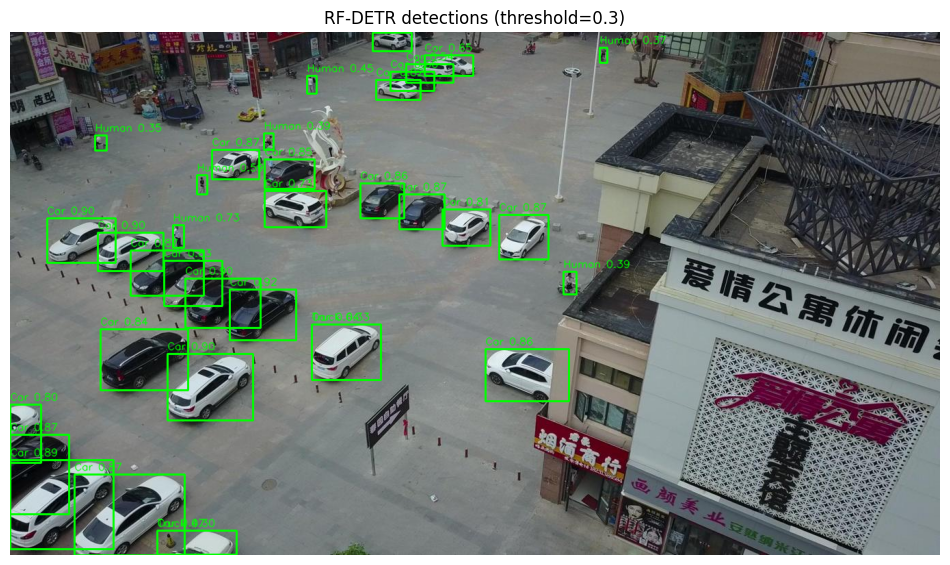

In [2]:
# ============================================================
# Cell 2: Load trained RF-DETR + visualize detections
# ============================================================

from pathlib import Path
import random
import torch
import cv2
import matplotlib.pyplot as plt

# -----------------------------
# 1) Paths + config
# -----------------------------
PHASE_ROOT = Path.cwd().parent.parent
RFDETR_MODELS_DIR = PHASE_ROOT / "rfdetr" / "models"
ENHANCED_RFDETR_MODELS_DIR = RFDETR_MODELS_DIR / "enhanced-training"

CKPT_PATH = ENHANCED_RFDETR_MODELS_DIR / "visdrone_rfdetr_nano_best_ema.pth"
VAL_IMG_DIR = PHASE_ROOT / "visdrone-dataset-rgb" / "val" / "images"

THRESHOLD = 0.30

# Phase class names
PHASE_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Other",
}

assert CKPT_PATH.exists(), f"Checkpoint not found: {CKPT_PATH}"
assert VAL_IMG_DIR.exists(), f"Val image dir not found: {VAL_IMG_DIR}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Checkpoint:", CKPT_PATH)

# -----------------------------
# 2) Load model (RF-DETR supported path)
# -----------------------------
global DETECTOR, _DETECTOR_CKPT
if "DETECTOR" not in globals() or "_DETECTOR_CKPT" not in globals() or _DETECTOR_CKPT != str(CKPT_PATH):
    print("Loading detector from checkpoint...")
    DETECTOR = RFDETRNano(pretrain_weights=str(CKPT_PATH))
    _DETECTOR_CKPT = str(CKPT_PATH)

DETECTOR.model.model.to(device)
DETECTOR.model.model.eval()
print("Detector loaded and ready.")

# -----------------------------
# 3) Pick a random image and run prediction
# -----------------------------
imgs = list(VAL_IMG_DIR.glob("*.jpg"))
assert imgs, f"No images found in: {VAL_IMG_DIR}"

image_path = str(random.choice(imgs))
print("Sanity test image:", image_path)

det = DETECTOR.predict(image_path, threshold=THRESHOLD)
print(f"Detections: {len(det.xyxy)} (threshold={THRESHOLD})")

# -----------------------------
# 4) Visualize boxes
# -----------------------------
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

for box, score, cls in zip(det.xyxy, det.confidence, det.class_id):
    x1, y1, x2, y2 = map(int, box.tolist())
    cls = int(cls)
    label = PHASE_CLASSES.get(cls, f"class_{cls}")
    text = f"{label} {float(score):.2f}"

    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        img_rgb,
        text,
        (x1, max(0, y1 - 6)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"RF-DETR detections (threshold={THRESHOLD})")
plt.show()

In [3]:
# ============================================================
# Cell 3: Initialize ByteTrack
# ============================================================

import inspect
import numpy as np
import cv2

assert SUPERVISION_OK, "supervision is not installed/importable. Install with: pip install supervision"

# ---- Desired tracking settings (we'll tune later) ----
TRACK_THRESH = 0.30
TRACK_BUFFER = 30
MATCH_THRESH = 0.80
FRAME_RATE   = 30

# ---- Build kwargs based on what this supervision version supports ----
sig = inspect.signature(sv.ByteTrack.__init__)
params = set(sig.parameters.keys())

kwargs = {}

# Newer supervision naming
if "track_activation_threshold" in params:
    kwargs["track_activation_threshold"] = TRACK_THRESH
if "lost_track_buffer" in params:
    kwargs["lost_track_buffer"] = TRACK_BUFFER
if "minimum_matching_threshold" in params:
    kwargs["minimum_matching_threshold"] = MATCH_THRESH
if "frame_rate" in params:
    kwargs["frame_rate"] = FRAME_RATE

# Older naming (what we tried originally)
if "track_thresh" in params:
    kwargs["track_thresh"] = TRACK_THRESH
if "track_buffer" in params:
    kwargs["track_buffer"] = TRACK_BUFFER
if "match_thresh" in params:
    kwargs["match_thresh"] = MATCH_THRESH

# Fallback: if none of these are accepted, instantiate without args
try:
    TRACKER = sv.ByteTrack(**kwargs)
except TypeError:
    TRACKER = sv.ByteTrack()

print("ByteTrack initialized")
print("ByteTrack init kwargs used:", kwargs)

# -----------------------------
# Helper: RF-DETR detections -> supervision.Detections
# -----------------------------
def rfdetr_to_sv_detections(det, min_conf=0.30):
    xyxy = np.asarray(det.xyxy, dtype=np.float32)
    conf = np.asarray(det.confidence, dtype=np.float32)
    cls  = np.asarray(det.class_id, dtype=np.int32)

    keep = conf >= float(min_conf)
    return sv.Detections(
        xyxy=xyxy[keep],
        confidence=conf[keep],
        class_id=cls[keep]
    )

# -----------------------------
# Helper: Draw tracks
# -----------------------------
def draw_tracks(frame_bgr, detections: "sv.Detections", class_map: dict, show_conf=True):
    out = frame_bgr.copy()
    tracker_ids = getattr(detections, "tracker_id", None)

    for i, box in enumerate(detections.xyxy):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls = int(detections.class_id[i]) if detections.class_id is not None else -1
        conf = float(detections.confidence[i]) if detections.confidence is not None else 0.0

        tid = int(tracker_ids[i]) if tracker_ids is not None and tracker_ids[i] is not None else -1
        label = class_map.get(cls, f"class_{cls}")

        text = f"ID {tid}: {label}" if tid >= 0 else label
        if show_conf:
            text += f" {conf:.2f}"

        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(out, text, (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)

    return out

print("Helpers ready: rfdetr_to_sv_detections(), draw_tracks()")

ByteTrack initialized
ByteTrack init kwargs used: {'track_activation_threshold': 0.3, 'lost_track_buffer': 30, 'minimum_matching_threshold': 0.8, 'frame_rate': 30}
Helpers ready: rfdetr_to_sv_detections(), draw_tracks()


In [4]:
# ============================================================
# Cell 4: Frames folder OR video file -> Detect (every N) -> ByteTrack -> Output mp4
# ============================================================

from pathlib import Path
import cv2
import numpy as np
from tqdm.auto import tqdm

# -----------------------------
# 1) Input configuration
# -----------------------------
# FRAMES_DIR = Path(PHASE_ROOT) / "rfdetr" / "videos" / "uav0000120_04775_v"
VIDEO_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "single_average_passenger_car.mp4"

# OUTPUT_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "tracked_output_uav0000120_04775_v.mp4"
OUTPUT_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "tracked_output_single_average_passenger_car.mp4"

DETECT_EVERY_N = 1
DET_THRESHOLD  = 0.30
MIN_BOX_AREA   = 30 * 30

FPS = 30.0
CLASS_MAP = PHASE_CLASSES

assert (VIDEO_PATH is not None) or FRAMES_DIR.exists(), "Provide VIDEO_PATH or a valid FRAMES_DIR."

# -----------------------------
# 2) Build frame iterator
# -----------------------------
def list_frames(folder: Path):
    exts = (".jpg", ".jpeg", ".png")
    frames = [p for p in folder.iterdir() if p.suffix.lower() in exts]
    return sorted(frames, key=lambda p: p.name)

frames_list = None
cap = None

if VIDEO_PATH is not None:
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 1:
        fps = FPS
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
else:
    frames_list = list_frames(FRAMES_DIR)
    assert len(frames_list) > 0, f"No frames found in: {FRAMES_DIR}"
    first = cv2.imread(str(frames_list[0]))
    assert first is not None, f"Could not read first frame: {frames_list[0]}"
    height, width = first.shape[:2]
    fps = FPS
    total_frames = len(frames_list)

print("Input:", VIDEO_PATH if VIDEO_PATH is not None else str(FRAMES_DIR))
print(f"Frames: {total_frames} | Size: {width}x{height} | Output FPS: {fps}")
print(f"Detect every N: {DETECT_EVERY_N}")

# -----------------------------
# 3) Configure tracker and reset for a new sequence
# -----------------------------
try:
    if hasattr(TRACKER, "frame_rate"):
        TRACKER.frame_rate = int(round(fps))
except Exception:
    pass

# Reset tracker so old tracks don’t leak between runs (if supported)
if hasattr(TRACKER, "reset"):
    TRACKER.reset()

# Track metadata: track_id -> (class_id, confidence)
track_meta = {}

def build_tensors_from_detections(detections: "sv.Detections") -> np.ndarray:
    """
    ByteTrack tensor format: Nx5 [x1, y1, x2, y2, score]
    """
    if len(detections) == 0:
        return np.zeros((0, 5), dtype=np.float32)
    return np.hstack([
        detections.xyxy.astype(np.float32),
        detections.confidence.reshape(-1, 1).astype(np.float32),
    ])

def active_tracks_to_boxes_and_ids(tracker) -> tuple[list[np.ndarray], list[int]]:
    """
    Convert tracker.tracked_tracks to (boxes, ids).
    Each track has tlbr (x1,y1,x2,y2) and external_track_id.
    """
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

# -----------------------------
# 4) Video writer
# -----------------------------
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_PATH), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not open writer: {OUTPUT_PATH}"

# -----------------------------
# 5) Main loop
# -----------------------------
pbar = tqdm(total=total_frames, desc="Processing frames")

for frame_idx in range(total_frames):
    # Load frame
    if cap is not None:
        ok, frame_bgr = cap.read()
        if not ok:
            break
    else:
        frame_bgr = cv2.imread(str(frames_list[frame_idx]))
        if frame_bgr is None:
            continue

    # Detection frame?
    if frame_idx % DETECT_EVERY_N == 0:
        temp_path = "temp_frame.jpg"
        cv2.imwrite(temp_path, frame_bgr)

        det = DETECTOR.predict(temp_path, threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        # Filter tiny boxes
        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        # Advance tracker using tensors (core tracking update)
        tensors = build_tensors_from_detections(detections)
        _ = TRACKER.update_with_tensors(tensors)

        # ALSO run update_with_detections on detection frames to get tracker_id mapping
        det_with_ids = TRACKER.update_with_detections(detections)
        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                track_meta[tid] = (cls, conf)

    else:
        # No detections: predict/propagate tracks forward
        _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

    # Draw ACTIVE TRACKS every frame (so boxes persist)
    out = frame_bgr.copy()
    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)

    for box, tid in zip(boxes, ids):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls, conf = track_meta.get(tid, (-1, 0.0))
        label = CLASS_MAP.get(cls, f"class_{cls}") if cls != -1 else "unknown"
        text = f"ID {tid}: {label} {conf:.2f}"

        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(out, text, (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)

    writer.write(out)
    pbar.update(1)

pbar.close()
if cap is not None:
    cap.release()
writer.release()

print(f"\nDone. Saved tracked video to: {OUTPUT_PATH}")

Input: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\single_average_passenger_car.mp4
Frames: 64 | Size: 898x506 | Output FPS: 30.0
Detect every N: 1


Processing frames:   0%|          | 0/64 [00:00<?, ?it/s]


Done. Saved tracked video to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\tracked_output_single_average_passenger_car.mp4


# Speed Estimation
Detection + Tracking was accomplished above. Now we try determining speeds of objects using homography.

source: https://www.scitepress.org/Papers/2022/110936/110936.pdf

=== Calibration Frame Selected ===
Source              : video frame 35
Frame index         : 35
Frame shape (HxWxC) : (506, 898, 3)
Next step           : In Cell 6, click the 4 road-plane corners of one reference vehicle.
Saved calibration preview to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\calibration_frame_35.jpg


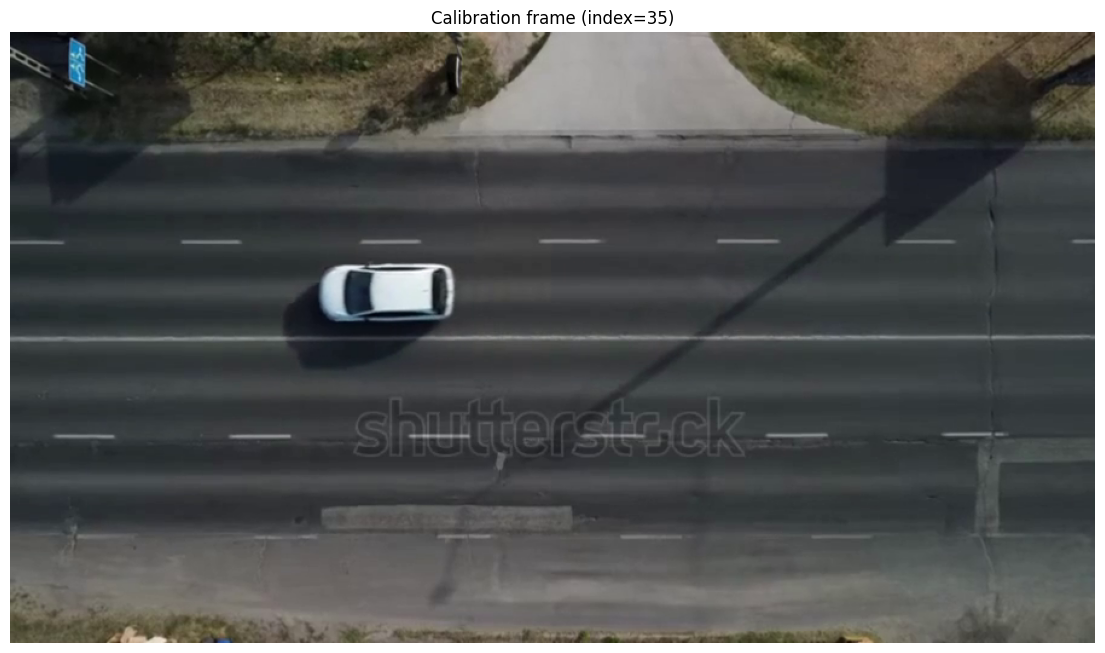

In [5]:
# ============================================================
# Cell 5: Select and display the calibration frame
# Purpose:
# - choose one good frame for homography initialization
# - save that frame for the next cell (manual corner picking)
# - keep this independent of detection/tracking for now
# ============================================================

from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1) Calibration frame settings
# -----------------------------
# Pick a frame where:
# - the road plane is clearly visible
# - one vehicle is clearly seen
# - the vehicle is not heavily occluded
# - the vehicle is preferably a passenger car
CALIBRATION_FRAME_IDX = 35   # <-- change as needed
SAVE_CALIBRATION_PREVIEW = True

# -----------------------------
# 2) Helper: read one frame by index
# -----------------------------
def read_frame_by_index(video_path=None, frames_list=None, frame_idx=0):
    """
    Returns:
        frame_bgr, source_text
    """
    if video_path is not None:
        cap_local = cv2.VideoCapture(str(video_path))
        assert cap_local.isOpened(), f"Could not open video: {video_path}"

        cap_local.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        ok, frame_bgr = cap_local.read()
        cap_local.release()

        assert ok and frame_bgr is not None, f"Could not read frame {frame_idx} from video: {video_path}"
        return frame_bgr, f"video frame {frame_idx}"

    else:
        assert frames_list is not None and len(frames_list) > 0, "frames_list is empty or not available."
        assert 0 <= frame_idx < len(frames_list), f"frame_idx out of range: {frame_idx}"
        frame_path = frames_list[frame_idx]
        frame_bgr = cv2.imread(str(frame_path))
        assert frame_bgr is not None, f"Could not read frame: {frame_path}"
        return frame_bgr, f"image file {frame_path.name}"

# -----------------------------
# 3) Load calibration frame
# -----------------------------
assert 0 <= CALIBRATION_FRAME_IDX < total_frames, (
    f"CALIBRATION_FRAME_IDX={CALIBRATION_FRAME_IDX} is outside [0, {total_frames-1}]"
)

calib_frame_bgr, calib_source = read_frame_by_index(
    video_path=VIDEO_PATH,
    frames_list=frames_list,
    frame_idx=CALIBRATION_FRAME_IDX
)

calib_frame_rgb = cv2.cvtColor(calib_frame_bgr, cv2.COLOR_BGR2RGB)

# Keep globally for later cells
CALIBRATION_FRAME_BGR = calib_frame_bgr.copy()
CALIBRATION_FRAME_RGB = calib_frame_rgb.copy()

print("=== Calibration Frame Selected ===")
print("Source              :", calib_source)
print("Frame index         :", CALIBRATION_FRAME_IDX)
print("Frame shape (HxWxC) :", CALIBRATION_FRAME_BGR.shape)
print("Next step           : In Cell 6, click the 4 road-plane corners of one reference vehicle.")
print("==================================")

# -----------------------------
# 4) Optional preview save
# -----------------------------
CALIBRATION_PREVIEW_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / f"calibration_frame_{CALIBRATION_FRAME_IDX}.jpg"

if SAVE_CALIBRATION_PREVIEW:
    CALIBRATION_PREVIEW_PATH.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(CALIBRATION_PREVIEW_PATH), cv2.cvtColor(CALIBRATION_FRAME_RGB, cv2.COLOR_RGB2BGR))
    print("Saved calibration preview to:", CALIBRATION_PREVIEW_PATH)

# -----------------------------
# 5) Display frame
# -----------------------------
plt.figure(figsize=(14, 8))
plt.imshow(CALIBRATION_FRAME_RGB)
plt.title(f"Calibration frame (index={CALIBRATION_FRAME_IDX})")
plt.axis("off")
plt.show()

=== Cell 6: Manual Corner Picking ===
Click the 4 tire-corner locations of ONE reference vehicle in this order:
  1. front-left tire location
  2. front-right tire location
  3. rear-right tire location
  4. rear-left tire location

Use the vehicle footprint on the ROAD plane.
If the tire contact points are not perfectly visible,
click the best visible approximation where the vehicle meets the road.

Controls:
  - Left click: add point
  - r: reset points
  - q: finish after 4 points

Selected image points:
  1 = front-left tire location
  2 = front-right tire location
  3 = rear-right tire location
  4 = rear-left tire location
  Point 1: (269.0, 235.0)
  Point 2: (269.0, 198.0)
  Point 3: (353.0, 194.0)
  Point 4: (353.0, 235.0)


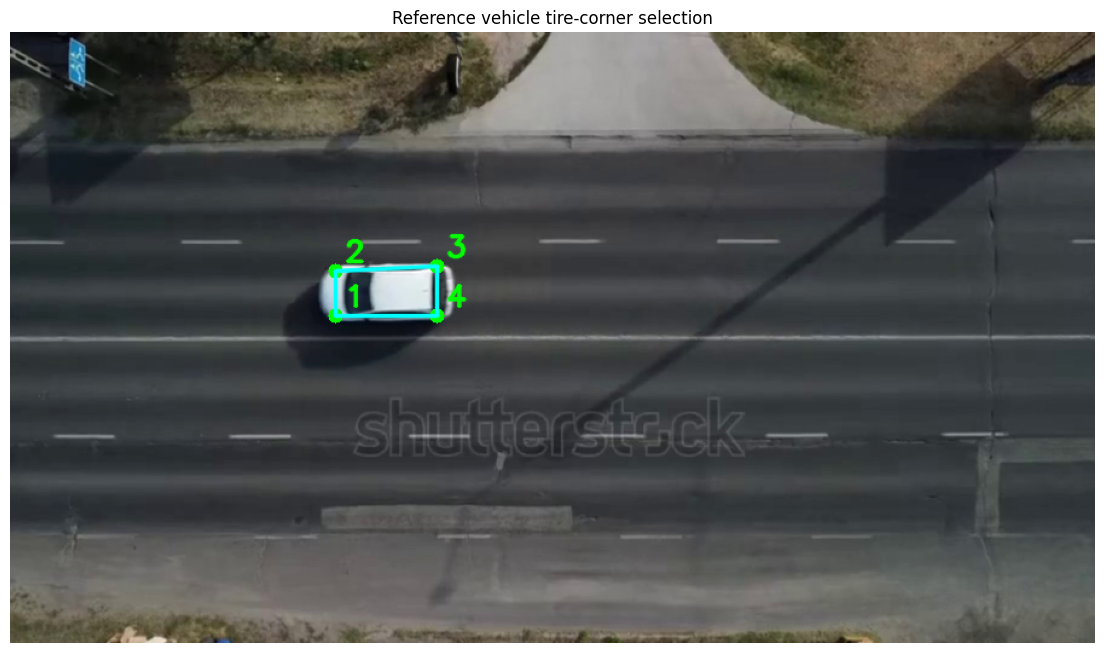

In [9]:
# ============================================================
# Cell 6: Manual corner picking on the reference vehicle
# Purpose:
# - click the 4 road-plane corners of ONE reference vehicle
# - store them in a consistent order
# - visualize the selected points for homography
#
# Click order (important):
#   1. front-left tire location
#   2. front-right tire location
#   3. rear-right tire location
#   4. rear-left tire location
#
# Notes:
# - click the vehicle footprint on the road plane
# - use the bottom outline where the tires/body meet the road
# - if the exact tire contact patch is not visible, click the best visible approximation
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assert "CALIBRATION_FRAME_BGR" in globals(), "Run Cell 5 first."

# -----------------------------
# 1) Config
# -----------------------------
REFERENCE_CLASS_NAME = "Car"
CLICK_WINDOW_NAME = "Cell 6 - Click 4 tire-corner locations"
POINT_RADIUS = 6
LINE_THICKNESS = 2
TEXT_SCALE = 0.8

# Global storage for mouse callback
clicked_points = []
display_img = CALIBRATION_FRAME_BGR.copy()

# -----------------------------
# 2) Mouse callback
# -----------------------------
def mouse_callback(event, x, y, flags, param):
    global clicked_points, display_img

    if event == cv2.EVENT_LBUTTONDOWN and len(clicked_points) < 4:
        clicked_points.append((x, y))

        # Draw point
        cv2.circle(display_img, (x, y), POINT_RADIUS, (0, 255, 0), -1)

        # Draw index label
        label = str(len(clicked_points))
        cv2.putText(
            display_img,
            label,
            (x + 8, y - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            TEXT_SCALE,
            (0, 255, 0),
            2,
            cv2.LINE_AA,
        )

        # Draw line from previous point
        if len(clicked_points) > 1:
            cv2.line(
                display_img,
                clicked_points[-2],
                clicked_points[-1],
                (255, 255, 0),
                LINE_THICKNESS,
                cv2.LINE_AA,
            )

        # Close polygon after 4th point
        if len(clicked_points) == 4:
            cv2.line(
                display_img,
                clicked_points[-1],
                clicked_points[0],
                (255, 255, 0),
                LINE_THICKNESS,
                cv2.LINE_AA,
            )

# -----------------------------
# 3) Instructions
# -----------------------------
print("=== Cell 6: Manual Corner Picking ===")
print("Click the 4 tire-corner locations of ONE reference vehicle in this order:")
print("  1. front-left tire location")
print("  2. front-right tire location")
print("  3. rear-right tire location")
print("  4. rear-left tire location")
print("")
print("Use the vehicle footprint on the ROAD plane.")
print("If the tire contact points are not perfectly visible,")
print("click the best visible approximation where the vehicle meets the road.")
print("")
print("Controls:")
print("  - Left click: add point")
print("  - r: reset points")
print("  - q: finish after 4 points")
print("=====================================")

# -----------------------------
# 4) Interactive point picking
# -----------------------------
cv2.namedWindow(CLICK_WINDOW_NAME, cv2.WINDOW_NORMAL)
cv2.resizeWindow(CLICK_WINDOW_NAME, 1100, 800)
cv2.setMouseCallback(CLICK_WINDOW_NAME, mouse_callback)

while True:
    cv2.imshow(CLICK_WINDOW_NAME, display_img)
    key = cv2.waitKey(20) & 0xFF

    if key == ord("r"):
        clicked_points = []
        display_img = CALIBRATION_FRAME_BGR.copy()
        print("Points reset. Click again.")

    elif key == ord("q"):
        if len(clicked_points) == 4:
            break
        print(f"You have selected {len(clicked_points)} point(s). Please select exactly 4.")

cv2.destroyAllWindows()

# -----------------------------
# 5) Save points in numpy format
# -----------------------------
assert len(clicked_points) == 4, f"Expected 4 points, got {len(clicked_points)}"

REFERENCE_VEHICLE_IMAGE_POINTS = np.array(clicked_points, dtype=np.float32)

print("\nSelected image points:")
print("  1 = front-left tire location")
print("  2 = front-right tire location")
print("  3 = rear-right tire location")
print("  4 = rear-left tire location")
for i, (x, y) in enumerate(REFERENCE_VEHICLE_IMAGE_POINTS, start=1):
    print(f"  Point {i}: ({x:.1f}, {y:.1f})")

# -----------------------------
# 6) Visual confirmation in matplotlib
# -----------------------------
preview_bgr = CALIBRATION_FRAME_BGR.copy()

for i, (x, y) in enumerate(REFERENCE_VEHICLE_IMAGE_POINTS.astype(int), start=1):
    cv2.circle(preview_bgr, (x, y), POINT_RADIUS, (0, 255, 0), -1)
    cv2.putText(
        preview_bgr,
        str(i),
        (x + 8, y - 8),
        cv2.FONT_HERSHEY_SIMPLEX,
        TEXT_SCALE,
        (0, 255, 0),
        2,
        cv2.LINE_AA,
    )

pts_int = REFERENCE_VEHICLE_IMAGE_POINTS.astype(int)
for i in range(4):
    p1 = tuple(pts_int[i])
    p2 = tuple(pts_int[(i + 1) % 4])
    cv2.line(preview_bgr, p1, p2, (255, 255, 0), LINE_THICKNESS, cv2.LINE_AA)

REFERENCE_VEHICLE_PREVIEW_BGR = preview_bgr.copy()
REFERENCE_VEHICLE_PREVIEW_RGB = cv2.cvtColor(preview_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(REFERENCE_VEHICLE_PREVIEW_RGB)
plt.title("Reference vehicle tire-corner selection")
plt.axis("off")
plt.show()

In [15]:
# ============================================================
# Cell 7: Define assumed real-world dimensions for reference vehicle
# Purpose:
# - assign real-world dimensions to the clicked reference vehicle
# - build the destination rectangle in metric ground-plane coordinates
# - keep everything ready for homography estimation in Cell 8
#
# Point order from Cell 6:
#   1. front-left tire location
#   2. front-right tire location
#   3. rear-right tire location
#   4. rear-left tire location
# ============================================================

import numpy as np

assert "REFERENCE_VEHICLE_IMAGE_POINTS" in globals(), "Run Cell 6 first."

# -----------------------------
# 1) Assumed reference dimensions (meters)
# -----------------------------
# Paper 1 uses average passenger-vehicle dimensions as the metric reference
# These are reasonable starting values for an average sedan/passenger car
REFERENCE_VEHICLE_WIDTH_M  = 1.80
REFERENCE_VEHICLE_LENGTH_M = 4.50

# Optional descriptive label
REFERENCE_VEHICLE_TYPE = "passenger_car"

# -----------------------------
# 2) Build destination rectangle in ground-plane coordinates
# -----------------------------
# We define a local 2D road-plane coordinate system in meters:
#
#   x-axis = vehicle width direction
#   y-axis = vehicle length direction
#
# The reference rectangle is placed with rear-left at y=0 and front edge at y=length
#
# IMPORTANT:
# This destination point order must match the image-point order:
#   1. front-left tire location
#   2. front-right tire location
#   3. rear-right tire location
#   4. rear-left tire location
#
REFERENCE_VEHICLE_WORLD_POINTS = np.array([
    [0.0,                        REFERENCE_VEHICLE_LENGTH_M],  # front-left
    [REFERENCE_VEHICLE_WIDTH_M,  REFERENCE_VEHICLE_LENGTH_M],  # front-right
    [REFERENCE_VEHICLE_WIDTH_M,  0.0],                         # rear-right
    [0.0,                        0.0],                         # rear-left
], dtype=np.float32)

# -----------------------------
# 3) Quick geometric sanity checks
# -----------------------------
img_pts = REFERENCE_VEHICLE_IMAGE_POINTS.astype(np.float32)
world_pts = REFERENCE_VEHICLE_WORLD_POINTS.astype(np.float32)

print("=== Cell 7: Reference Vehicle Dimensions ===")
print("Reference vehicle type :", REFERENCE_VEHICLE_TYPE)
print(f"Assumed width  (m)     : {REFERENCE_VEHICLE_WIDTH_M:.3f}")
print(f"Assumed length (m)     : {REFERENCE_VEHICLE_LENGTH_M:.3f}")
print("")

print("Image points from Cell 6 (pixels):")
for i, (x, y) in enumerate(img_pts, start=1):
    print(f"  Point {i}: ({x:.1f}, {y:.1f})")

print("")
print("Destination world points (meters):")
for i, (x, y) in enumerate(world_pts, start=1):
    print(f"  Point {i}: ({x:.3f}, {y:.3f})")

# -----------------------------
# 4) Store useful derived values
# -----------------------------
REFERENCE_VEHICLE_DIMENSIONS = {
    "type": REFERENCE_VEHICLE_TYPE,
    "width_m": float(REFERENCE_VEHICLE_WIDTH_M),
    "length_m": float(REFERENCE_VEHICLE_LENGTH_M),
}

# Approximate pixel side lengths on the selected quadrilateral
def euclidean(p1, p2):
    return float(np.linalg.norm(np.asarray(p1, dtype=np.float32) - np.asarray(p2, dtype=np.float32)))

REFERENCE_IMAGE_SIDE_LENGTHS = {
    "front_edge_px": euclidean(img_pts[0], img_pts[1]),
    "right_edge_px": euclidean(img_pts[1], img_pts[2]),
    "rear_edge_px":  euclidean(img_pts[2], img_pts[3]),
    "left_edge_px":  euclidean(img_pts[3], img_pts[0]),
}

print("")
print("Approximate image-side lengths (pixels):")
for k, v in REFERENCE_IMAGE_SIDE_LENGTHS.items():
    print(f"  {k:15s}: {v:.2f}")

print("")
print("Outputs created for Cell 8:")
print("  - REFERENCE_VEHICLE_IMAGE_POINTS")
print("  - REFERENCE_VEHICLE_WORLD_POINTS")
print("  - REFERENCE_VEHICLE_DIMENSIONS")
print("==========================================")

=== Cell 7: Reference Vehicle Dimensions ===
Reference vehicle type : passenger_car
Assumed width  (m)     : 1.800
Assumed length (m)     : 4.500

Image points from Cell 6 (pixels):
  Point 1: (269.0, 235.0)
  Point 2: (269.0, 198.0)
  Point 3: (353.0, 194.0)
  Point 4: (353.0, 235.0)

Destination world points (meters):
  Point 1: (0.000, 4.500)
  Point 2: (1.800, 4.500)
  Point 3: (1.800, 0.000)
  Point 4: (0.000, 0.000)

Approximate image-side lengths (pixels):
  front_edge_px  : 37.00
  right_edge_px  : 84.10
  rear_edge_px   : 41.00
  left_edge_px   : 84.00

Outputs created for Cell 8:
  - REFERENCE_VEHICLE_IMAGE_POINTS
  - REFERENCE_VEHICLE_WORLD_POINTS
  - REFERENCE_VEHICLE_DIMENSIONS


=== Cell 8: Homography Computation ===
H_IMG_TO_WORLD:
[[-1.24580268e-17 -7.44094501e-02  1.74862208e+01]
 [-8.19389803e-02  1.79008302e-18  2.89244601e+01]
 [ 1.96850421e-03  2.66720246e-18  1.00000000e+00]]

H_WORLD_TO_IMG:
[[ 7.29234592e-15 -7.20062147e+00  2.08274088e+02]
 [-1.34391532e+01  3.33099661e+00  1.38652721e+02]
 [ 2.14899289e-17  1.41744537e-02  5.90011581e-01]]

Image points projected into world space:
  Point 1: (0.0000, 4.5000) m | target=(0.0000, 4.5000)
  Point 2: (1.8000, 4.5000) m | target=(1.8000, 4.5000)
  Point 3: (1.8000, 0.0000) m | target=(1.8000, 0.0000)
  Point 4: (0.0000, 0.0000) m | target=(0.0000, 0.0000)

World-space corner errors (meters):
  Point 1: 0.00000000
  Point 2: 0.00000000
  Point 3: 0.00000000
  Point 4: 0.00000000

World points reprojected into image space:
  Point 1: (269.0000, 235.0000) px | target=(269.0000, 235.0000)
  Point 2: (269.0000, 198.0000) px | target=(269.0000, 198.0000)
  Point 3: (353.0000, 194.0000) px | target=(353.0000, 

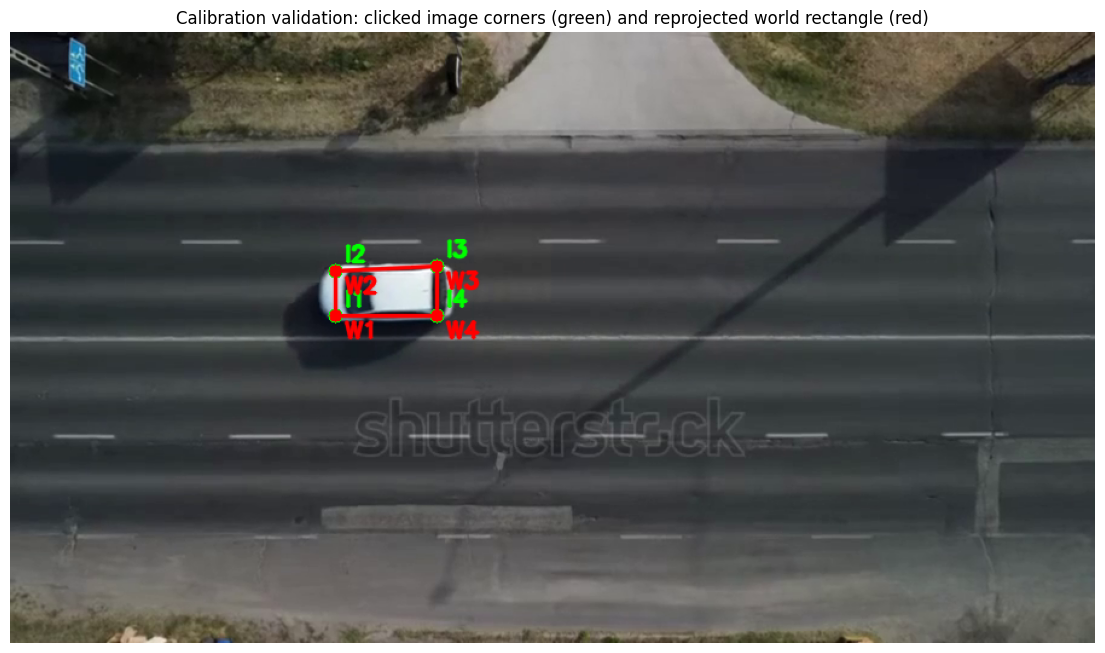

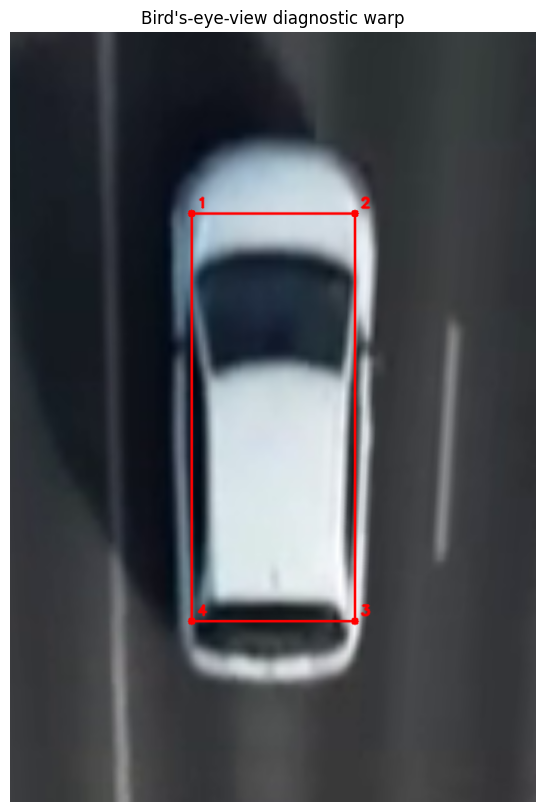


Saved validation overlay to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\homography_validation_overlay_frame_35.jpg
Saved BEV diagnostic to    : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\homography_bev_diagnostic_frame_35.jpg

Interpretation guide:
- Green points are your clicked image points.
- Red points/box are the world rectangle projected back into the image.
- In this 4-point setup, reprojection error should be near zero.
- The BEV diagnostic is more important: it should look geometrically plausible.
- If the BEV looks badly skewed or unrealistic, redo Cell 6 with better road-contact points.

Outputs created for later cells:
  - HOMOGRAPHY_IMG_TO_WORLD / H_IMG_TO_WORLD
  - HOMOGRAPHY_WORLD_TO_IMG / H_WORLD_TO_IMG
  - project_points_homography()
  - project_point_homography()


In [16]:
# ============================================================
# Cell 8: Compute homography and validate calibration
# Purpose:
# - estimate image -> ground-plane homography from the reference vehicle
# - estimate inverse homography (ground-plane -> image)
# - validate the mapping numerically and visually
# - create helpers for projecting points between spaces
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assert "REFERENCE_VEHICLE_IMAGE_POINTS" in globals(), "Run Cell 6 first."
assert "REFERENCE_VEHICLE_WORLD_POINTS" in globals(), "Run Cell 7 first."
assert "CALIBRATION_FRAME_BGR" in globals(), "Run Cell 5 first."

# -----------------------------
# 1) Compute homography
# -----------------------------
img_pts = REFERENCE_VEHICLE_IMAGE_POINTS.astype(np.float32)
world_pts = REFERENCE_VEHICLE_WORLD_POINTS.astype(np.float32)

H_IMG_TO_WORLD = cv2.getPerspectiveTransform(img_pts, world_pts)
H_WORLD_TO_IMG = np.linalg.inv(H_IMG_TO_WORLD)

print("=== Cell 8: Homography Computation ===")
print("H_IMG_TO_WORLD:")
print(H_IMG_TO_WORLD)
print("")
print("H_WORLD_TO_IMG:")
print(H_WORLD_TO_IMG)
print("======================================")

# -----------------------------
# 2) Helper functions
# -----------------------------
def project_points_homography(points_xy, H):
    """
    Project Nx2 points through homography H.
    Input:
        points_xy : array-like of shape (N, 2)
        H         : 3x3 homography
    Returns:
        projected : np.ndarray of shape (N, 2)
    """
    pts = np.asarray(points_xy, dtype=np.float32).reshape(-1, 1, 2)
    warped = cv2.perspectiveTransform(pts, H)
    return warped.reshape(-1, 2)

def project_point_homography(point_xy, H):
    """
    Project a single 2D point through homography H.
    """
    return project_points_homography([point_xy], H)[0]

# Store helpers globally for later cells
HOMOGRAPHY_IMG_TO_WORLD = H_IMG_TO_WORLD.copy()
HOMOGRAPHY_WORLD_TO_IMG = H_WORLD_TO_IMG.copy()

# -----------------------------
# 3) Numerical validation:
#    image -> world should recover the destination rectangle
# -----------------------------
projected_world_from_image = project_points_homography(img_pts, H_IMG_TO_WORLD)
reprojection_image_from_world = project_points_homography(world_pts, H_WORLD_TO_IMG)

world_errors = np.linalg.norm(projected_world_from_image - world_pts, axis=1)
image_errors = np.linalg.norm(reprojection_image_from_world - img_pts, axis=1)

print("\nImage points projected into world space:")
for i, p in enumerate(projected_world_from_image, start=1):
    print(f"  Point {i}: ({p[0]:.4f}, {p[1]:.4f}) m | target=({world_pts[i-1,0]:.4f}, {world_pts[i-1,1]:.4f})")

print("\nWorld-space corner errors (meters):")
for i, e in enumerate(world_errors, start=1):
    print(f"  Point {i}: {e:.8f}")

print("\nWorld points reprojected into image space:")
for i, p in enumerate(reprojection_image_from_world, start=1):
    print(f"  Point {i}: ({p[0]:.4f}, {p[1]:.4f}) px | target=({img_pts[i-1,0]:.4f}, {img_pts[i-1,1]:.4f})")

print("\nImage-space reprojection errors (pixels):")
for i, e in enumerate(image_errors, start=1):
    print(f"  Point {i}: {e:.8f}")

# -----------------------------
# 4) Visual validation on image:
#    reproject the world rectangle back onto the frame
# -----------------------------
overlay_bgr = CALIBRATION_FRAME_BGR.copy()

# Draw original clicked image points in green
for i, (x, y) in enumerate(img_pts.astype(int), start=1):
    cv2.circle(overlay_bgr, (x, y), 6, (0, 255, 0), -1)
    cv2.putText(
        overlay_bgr,
        f"I{i}",
        (x + 8, y - 8),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2,
        cv2.LINE_AA,
    )

# Draw reprojected world rectangle in red
reproj_int = np.round(reprojection_image_from_world).astype(int)
for i, (x, y) in enumerate(reproj_int, start=1):
    cv2.circle(overlay_bgr, (x, y), 5, (0, 0, 255), -1)
    cv2.putText(
        overlay_bgr,
        f"W{i}",
        (x + 8, y + 18),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2,
        cv2.LINE_AA,
    )

for i in range(4):
    p1 = tuple(reproj_int[i])
    p2 = tuple(reproj_int[(i + 1) % 4])
    cv2.line(overlay_bgr, p1, p2, (0, 0, 255), 2, cv2.LINE_AA)

overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(overlay_rgb)
plt.title("Calibration validation: clicked image corners (green) and reprojected world rectangle (red)")
plt.axis("off")
plt.show()

# -----------------------------
# 5) Bird's-eye-view style diagnostic
#    Warp the whole image into a metric canvas
# -----------------------------
# We create a top-down canvas in pixels, where 1 meter = BEV_PIXELS_PER_METER
BEV_PIXELS_PER_METER = 120
BEV_MARGIN_M = 2.0

world_w_m = float(REFERENCE_VEHICLE_DIMENSIONS["width_m"] + 2 * BEV_MARGIN_M)
world_h_m = float(REFERENCE_VEHICLE_DIMENSIONS["length_m"] + 2 * BEV_MARGIN_M)

bev_w = int(np.ceil(world_w_m * BEV_PIXELS_PER_METER))
bev_h = int(np.ceil(world_h_m * BEV_PIXELS_PER_METER))

# Shift world coordinates so the vehicle rectangle sits inside the canvas margin
T_world_to_bev = np.array([
    [BEV_PIXELS_PER_METER, 0, BEV_MARGIN_M * BEV_PIXELS_PER_METER],
    [0, -BEV_PIXELS_PER_METER, (REFERENCE_VEHICLE_DIMENSIONS["length_m"] + BEV_MARGIN_M) * BEV_PIXELS_PER_METER],
    [0, 0, 1]
], dtype=np.float64)

H_IMG_TO_BEV = T_world_to_bev @ H_IMG_TO_WORLD
BEV_WARP = cv2.warpPerspective(CALIBRATION_FRAME_BGR, H_IMG_TO_BEV, (bev_w, bev_h))
BEV_WARP_RGB = cv2.cvtColor(BEV_WARP, cv2.COLOR_BGR2RGB)

# Draw the reference rectangle on BEV image for visual sanity
bev_overlay = BEV_WARP_RGB.copy()
world_rect_for_bev = world_pts.copy()
world_rect_h = np.concatenate([world_rect_for_bev, np.ones((4, 1), dtype=np.float32)], axis=1)
bev_pts_h = (T_world_to_bev @ world_rect_h.T).T
bev_pts = bev_pts_h[:, :2] / bev_pts_h[:, 2:3]
bev_pts_int = np.round(bev_pts).astype(int)

for i, (x, y) in enumerate(bev_pts_int, start=1):
    cv2.circle(bev_overlay, (x, y), 5, (255, 0, 0), -1)
    cv2.putText(
        bev_overlay,
        str(i),
        (x + 8, y - 8),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2,
        cv2.LINE_AA,
    )

for i in range(4):
    p1 = tuple(bev_pts_int[i])
    p2 = tuple(bev_pts_int[(i + 1) % 4])
    cv2.line(bev_overlay, p1, p2, (255, 0, 0), 2, cv2.LINE_AA)

plt.figure(figsize=(8, 10))
plt.imshow(bev_overlay)
plt.title("Bird's-eye-view diagnostic warp")
plt.axis("off")
plt.show()

# -----------------------------
# 6) Save diagnostics
# -----------------------------
HOMOGRAPHY_VALIDATION_OVERLAY_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / f"homography_validation_overlay_frame_{CALIBRATION_FRAME_IDX}.jpg"
BEV_DIAGNOSTIC_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / f"homography_bev_diagnostic_frame_{CALIBRATION_FRAME_IDX}.jpg"

cv2.imwrite(str(HOMOGRAPHY_VALIDATION_OVERLAY_PATH), cv2.cvtColor(overlay_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(BEV_DIAGNOSTIC_PATH), cv2.cvtColor(bev_overlay, cv2.COLOR_RGB2BGR))

print("\nSaved validation overlay to:", HOMOGRAPHY_VALIDATION_OVERLAY_PATH)
print("Saved BEV diagnostic to    :", BEV_DIAGNOSTIC_PATH)

# -----------------------------
# 7) Simple interpretation note
# -----------------------------
print("\nInterpretation guide:")
print("- Green points are your clicked image points.")
print("- Red points/box are the world rectangle projected back into the image.")
print("- In this 4-point setup, reprojection error should be near zero.")
print("- The BEV diagnostic is more important: it should look geometrically plausible.")
print("- If the BEV looks badly skewed or unrealistic, redo Cell 6 with better road-contact points.")

# Outputs for later cells
print("\nOutputs created for later cells:")
print("  - HOMOGRAPHY_IMG_TO_WORLD / H_IMG_TO_WORLD")
print("  - HOMOGRAPHY_WORLD_TO_IMG / H_WORLD_TO_IMG")
print("  - project_points_homography()")
print("  - project_point_homography()")

In [23]:
# ============================================================
# Cell 9: Geometry + speed helper functions
# Purpose:
# - define reusable helpers for speed estimation
# - convert boxes -> representative points
# - reject unstable border-region boxes
# - project image points -> world points
# - compute displacement, time, and speed
# ============================================================

import cv2
import numpy as np

assert "HOMOGRAPHY_IMG_TO_WORLD" in globals(), "Run Cell 8 first."

# -----------------------------
# 1) Core configuration
# -----------------------------
SPEED_ESTIMATION_CLASS_IDS = {3, 4, 5, 6}

MIN_TRACK_HISTORY_FOR_SPEED = 2
DEFAULT_SPEED_WINDOW = 5
MAX_REASONABLE_SPEED_KMH = 250.0
MIN_REASONABLE_SPEED_KMH = 0.0

# Representative-point mode:
#   "bottom_center" -> closer to Paper 1
#   "center"        -> better for top-down / bird's-eye video
REPRESENTATIVE_POINT_MODE = "center"

BOTTOM_CENTER_Y_OFFSET_PX = 0.0

# Border exclusion settings
BORDER_MARGIN_PX = 20

# -----------------------------
# 2) Bounding-box geometry
# -----------------------------
def bbox_bottom_center_xyxy(box_xyxy, y_offset_px=0.0):
    x1, y1, x2, y2 = map(float, box_xyxy)
    cx = 0.5 * (x1 + x2)
    cy = y2 + float(y_offset_px)
    return np.array([cx, cy], dtype=np.float32)

def bbox_center_xyxy(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0], dtype=np.float32)

def bbox_area_xyxy(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)

def bbox_touches_border(box_xyxy, image_width, image_height, margin_px=BORDER_MARGIN_PX):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return (
        x1 <= margin_px or
        y1 <= margin_px or
        x2 >= (image_width - margin_px) or
        y2 >= (image_height - margin_px)
    )

def representative_point_xyxy(box_xyxy, mode=REPRESENTATIVE_POINT_MODE):
    if mode == "center":
        return bbox_center_xyxy(box_xyxy)
    elif mode == "bottom_center":
        return bbox_bottom_center_xyxy(box_xyxy, y_offset_px=BOTTOM_CENTER_Y_OFFSET_PX)
    else:
        raise ValueError(f"Unsupported REPRESENTATIVE_POINT_MODE={mode}")

# -----------------------------
# 3) Homography projection
# -----------------------------
def image_to_world_point(point_xy, H=None):
    if H is None:
        H = HOMOGRAPHY_IMG_TO_WORLD
    point_xy = np.asarray(point_xy, dtype=np.float32).reshape(1, 1, 2)
    world_xy = cv2.perspectiveTransform(point_xy, H).reshape(2)
    return world_xy.astype(np.float32)

def image_to_world_points(points_xy, H=None):
    if H is None:
        H = HOMOGRAPHY_IMG_TO_WORLD
    pts = np.asarray(points_xy, dtype=np.float32).reshape(-1, 1, 2)
    world_xy = cv2.perspectiveTransform(pts, H).reshape(-1, 2)
    return world_xy.astype(np.float32)

# -----------------------------
# 4) Distance / time / speed
# -----------------------------
def euclidean_distance_m(p1_world, p2_world):
    p1 = np.asarray(p1_world, dtype=np.float32)
    p2 = np.asarray(p2_world, dtype=np.float32)
    return float(np.linalg.norm(p2 - p1))

def frames_to_seconds(frame_delta, fps):
    fps = float(fps)
    if fps <= 0:
        raise ValueError(f"Invalid fps={fps}")
    return float(frame_delta) / fps

def speed_mps_from_positions(p1_world, p2_world, frame_delta, fps):
    dt = frames_to_seconds(frame_delta, fps)
    if dt <= 0:
        return None
    dist_m = euclidean_distance_m(p1_world, p2_world)
    return dist_m / dt

def mps_to_kmh(speed_mps):
    if speed_mps is None:
        return None
    return float(speed_mps) * 3.6

def kmh_to_mps(speed_kmh):
    return float(speed_kmh) / 3.6

def speed_kmh_from_positions(p1_world, p2_world, frame_delta, fps):
    speed_mps = speed_mps_from_positions(p1_world, p2_world, frame_delta, fps)
    if speed_mps is None:
        return None
    return mps_to_kmh(speed_mps)

# -----------------------------
# 5) Simple smoothing / filtering
# -----------------------------
def is_reasonable_speed_kmh(speed_kmh,
                            min_kmh=MIN_REASONABLE_SPEED_KMH,
                            max_kmh=MAX_REASONABLE_SPEED_KMH):
    if speed_kmh is None:
        return False
    return float(min_kmh) <= float(speed_kmh) <= float(max_kmh)

def moving_average(values, window=DEFAULT_SPEED_WINDOW):
    valid = [float(v) for v in values if v is not None]
    if len(valid) == 0:
        return None
    valid = valid[-int(window):]
    return float(np.mean(valid))

# -----------------------------
# 6) Track-history initialization helpers
# -----------------------------
def make_empty_track_history(speed_window=DEFAULT_SPEED_WINDOW):
    return {
        "frames": [],
        "image_points": [],
        "world_points": [],
        "raw_speeds_kmh": [],
        "smoothed_speeds_kmh": [],
        "last_box": None,
        "class_id": None,
        "confidence": None,
        "speed_window": int(speed_window),
    }

def append_track_observation(track_history, frame_idx, box_xyxy, class_id, confidence, fps):
    img_pt = representative_point_xyxy(box_xyxy, mode=REPRESENTATIVE_POINT_MODE)
    world_pt = image_to_world_point(img_pt)

    track_history["frames"].append(int(frame_idx))
    track_history["image_points"].append(img_pt)
    track_history["world_points"].append(world_pt)
    track_history["last_box"] = np.asarray(box_xyxy, dtype=np.float32)
    track_history["class_id"] = int(class_id) if class_id is not None else None
    track_history["confidence"] = float(confidence) if confidence is not None else None

    raw_speed_kmh = None
    if len(track_history["world_points"]) >= 2:
        p1 = track_history["world_points"][-2]
        p2 = track_history["world_points"][-1]
        f1 = track_history["frames"][-2]
        f2 = track_history["frames"][-1]
        frame_delta = f2 - f1

        raw_speed_kmh = speed_kmh_from_positions(p1, p2, frame_delta, fps)
        if raw_speed_kmh is not None and not is_reasonable_speed_kmh(raw_speed_kmh):
            raw_speed_kmh = None

    track_history["raw_speeds_kmh"].append(raw_speed_kmh)

    smoothed_speed_kmh = moving_average(
        track_history["raw_speeds_kmh"],
        window=track_history["speed_window"]
    )
    track_history["smoothed_speeds_kmh"].append(smoothed_speed_kmh)

    return track_history

def latest_speed_kmh(track_history, smoothed=True):
    key = "smoothed_speeds_kmh" if smoothed else "raw_speeds_kmh"
    if len(track_history[key]) == 0:
        return None
    return track_history[key][-1]

# -----------------------------
# 7) Quick sanity check
# -----------------------------
ref_img_pts = REFERENCE_VEHICLE_IMAGE_POINTS.copy()
ref_world_pts = image_to_world_points(ref_img_pts)

print("=== Cell 9: Helper Functions Ready ===")
print("Eligible class IDs for speed :", SPEED_ESTIMATION_CLASS_IDS)
print("Representative point mode    :", REPRESENTATIVE_POINT_MODE)
print("Border margin (px)           :", BORDER_MARGIN_PX)
print("Default smoothing window     :", DEFAULT_SPEED_WINDOW)
print("Max reasonable speed (km/h)  :", MAX_REASONABLE_SPEED_KMH)
print("")

print("Reference image points projected into world plane:")
for i, p in enumerate(ref_world_pts, start=1):
    print(f"  Point {i}: ({p[0]:.4f}, {p[1]:.4f}) m")

print("")
print("Created helpers:")
print("  - representative_point_xyxy()")
print("  - bbox_touches_border()")
print("  - image_to_world_point() / image_to_world_points()")
print("  - euclidean_distance_m()")
print("  - speed_mps_from_positions() / speed_kmh_from_positions()")
print("  - moving_average()")
print("  - make_empty_track_history()")
print("  - append_track_observation()")
print("  - latest_speed_kmh()")
print("======================================")

=== Cell 9: Helper Functions Ready ===
Eligible class IDs for speed : {3, 4, 5, 6}
Representative point mode    : center
Border margin (px)           : 20
Default smoothing window     : 5
Max reasonable speed (km/h)  : 250.0

Reference image points projected into world plane:
  Point 1: (0.0000, 4.5000) m
  Point 2: (1.8000, 4.5000) m
  Point 3: (1.8000, 0.0000) m
  Point 4: (0.0000, 0.0000) m

Created helpers:
  - representative_point_xyxy()
  - bbox_touches_border()
  - image_to_world_point() / image_to_world_points()
  - euclidean_distance_m()
  - speed_mps_from_positions() / speed_kmh_from_positions()
  - moving_average()
  - make_empty_track_history()
  - append_track_observation()
  - latest_speed_kmh()


In [24]:
# ============================================================
# Cell 10: Initialize per-track trajectory and speed state
# Purpose:
# - create persistent storage for each tracked object
# - keep image-space points, world-space points, and speed history
# - prepare reusable state for the speed-estimation loop
# ============================================================

from collections import defaultdict

assert "make_empty_track_history" in globals(), "Run Cell 9 first."

# -----------------------------
# 1) Track-history configuration
# -----------------------------
# Minimum number of observations before a track is considered mature enough
# to trust more for speed reporting.
MIN_TRACK_OBSERVATIONS = 3

# If a track disappears for too long, we can later decide to ignore or archive it
MAX_MISSING_FRAMES = 15

# Keep a registry for active and finished tracks
TRACK_HISTORIES = {}
FINISHED_TRACK_HISTORIES = {}

# Optional bookkeeping for last-seen frame
TRACK_LAST_SEEN_FRAME = {}

# Optional per-track status flags
TRACK_STATUS = defaultdict(lambda: {
    "is_active": True,
    "num_missing_frames": 0,
    "num_observations": 0,
    "has_valid_speed": False,
})

# -----------------------------
# 2) Helper: get/create history for a track
# -----------------------------
def get_or_create_track_history(track_id, speed_window=DEFAULT_SPEED_WINDOW):
    """
    Return an existing track history or create a new one.
    """
    track_id = int(track_id)
    if track_id not in TRACK_HISTORIES:
        TRACK_HISTORIES[track_id] = make_empty_track_history(speed_window=speed_window)
    return TRACK_HISTORIES[track_id]

# -----------------------------
# 3) Helper: mark track observed on a frame
# -----------------------------
def mark_track_observed(track_id, frame_idx):
    """
    Update bookkeeping when a track is seen on the current frame.
    """
    track_id = int(track_id)
    frame_idx = int(frame_idx)

    TRACK_LAST_SEEN_FRAME[track_id] = frame_idx
    TRACK_STATUS[track_id]["is_active"] = True
    TRACK_STATUS[track_id]["num_missing_frames"] = 0

    if track_id in TRACK_HISTORIES:
        TRACK_STATUS[track_id]["num_observations"] = len(TRACK_HISTORIES[track_id]["frames"])

        latest_speed = latest_speed_kmh(TRACK_HISTORIES[track_id], smoothed=True)
        TRACK_STATUS[track_id]["has_valid_speed"] = latest_speed is not None

# -----------------------------
# 4) Helper: update missing-frame counts for unseen tracks
# -----------------------------
def update_missing_tracks(active_track_ids_this_frame, frame_idx, max_missing_frames=MAX_MISSING_FRAMES):
    """
    For any known track not seen on this frame:
    - increment missing-frame count
    - mark inactive if missing too long
    - optionally move to finished registry
    """
    active_track_ids_this_frame = set(int(t) for t in active_track_ids_this_frame)
    frame_idx = int(frame_idx)

    for track_id in list(TRACK_HISTORIES.keys()):
        if track_id not in active_track_ids_this_frame:
            last_seen = TRACK_LAST_SEEN_FRAME.get(track_id, None)

            if last_seen is None:
                TRACK_STATUS[track_id]["num_missing_frames"] += 1
            else:
                TRACK_STATUS[track_id]["num_missing_frames"] = frame_idx - last_seen

            if TRACK_STATUS[track_id]["num_missing_frames"] > max_missing_frames:
                TRACK_STATUS[track_id]["is_active"] = False

                # Move to finished registry if not already there
                if track_id not in FINISHED_TRACK_HISTORIES:
                    FINISHED_TRACK_HISTORIES[track_id] = TRACK_HISTORIES[track_id]

# -----------------------------
# 5) Helper: decide whether a track is ready for speed display
# -----------------------------
def track_ready_for_speed(track_id, min_track_observations=MIN_TRACK_OBSERVATIONS):
    """
    A track is ready if it has enough observations and a valid latest speed.
    """
    track_id = int(track_id)

    if track_id not in TRACK_HISTORIES:
        return False

    hist = TRACK_HISTORIES[track_id]
    if len(hist["frames"]) < int(min_track_observations):
        return False

    latest = latest_speed_kmh(hist, smoothed=True)
    return latest is not None

# -----------------------------
# 6) Helper: summary for one track
# -----------------------------
def summarize_track_state(track_id):
    """
    Return a compact dictionary summary for debugging/inspection.
    """
    track_id = int(track_id)
    hist = TRACK_HISTORIES.get(track_id, None)
    status = TRACK_STATUS.get(track_id, {})

    if hist is None:
        return {
            "track_id": track_id,
            "exists": False,
        }

    return {
        "track_id": track_id,
        "exists": True,
        "num_frames": len(hist["frames"]),
        "last_frame": hist["frames"][-1] if len(hist["frames"]) > 0 else None,
        "class_id": hist["class_id"],
        "confidence": hist["confidence"],
        "latest_raw_speed_kmh": latest_speed_kmh(hist, smoothed=False),
        "latest_smoothed_speed_kmh": latest_speed_kmh(hist, smoothed=True),
        "is_active": status.get("is_active", None),
        "num_missing_frames": status.get("num_missing_frames", None),
        "num_observations": status.get("num_observations", None),
        "has_valid_speed": status.get("has_valid_speed", None),
    }

# -----------------------------
# 7) Initialization confirmation
# -----------------------------
print("=== Cell 10: Track State Initialized ===")
print("MIN_TRACK_OBSERVATIONS :", MIN_TRACK_OBSERVATIONS)
print("MAX_MISSING_FRAMES     :", MAX_MISSING_FRAMES)
print("")
print("Created state containers:")
print("  - TRACK_HISTORIES")
print("  - FINISHED_TRACK_HISTORIES")
print("  - TRACK_LAST_SEEN_FRAME")
print("  - TRACK_STATUS")
print("")
print("Created helpers:")
print("  - get_or_create_track_history()")
print("  - mark_track_observed()")
print("  - update_missing_tracks()")
print("  - track_ready_for_speed()")
print("  - summarize_track_state()")
print("========================================")

=== Cell 10: Track State Initialized ===
MIN_TRACK_OBSERVATIONS : 3
MAX_MISSING_FRAMES     : 15

Created state containers:
  - TRACK_HISTORIES
  - FINISHED_TRACK_HISTORIES
  - TRACK_LAST_SEEN_FRAME
  - TRACK_STATUS

Created helpers:
  - get_or_create_track_history()
  - mark_track_observed()
  - update_missing_tracks()
  - track_ready_for_speed()
  - summarize_track_state()


In [30]:
# ============================================================
# Cell 11: Extend the main loop to collect per-track observations
# Purpose:
# - rerun detection + tracking
# - for each eligible active track, compute its representative point
# - reject border-touching boxes from speed updates
# - project valid points into world coordinates
# - update per-track trajectory/speed history
# ============================================================

from pathlib import Path
import cv2
import numpy as np
from tqdm.auto import tqdm

assert "TRACKER" in globals(), "Run Cell 3 first."
assert "TRACK_HISTORIES" in globals(), "Run Cell 10 first."
assert "append_track_observation" in globals(), "Run Cell 9 first."

VIDEO_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "single_average_passenger_car.mp4"
OUTPUT_PATH_CELL11 = Path(PHASE_ROOT) / "rfdetr" / "videos" / "tracked_with_track_history_preview.mp4"

DETECT_EVERY_N = 1
DET_THRESHOLD  = 0.30
MIN_BOX_AREA   = 30 * 30

FPS = 30.0
CLASS_MAP = PHASE_CLASSES

cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"

fps = cap.get(cv2.CAP_PROP_FPS)
if fps is None or fps <= 1:
    fps = FPS
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("Input:", VIDEO_PATH)
print(f"Frames: {total_frames} | Size: {width}x{height} | FPS: {fps}")

try:
    if hasattr(TRACKER, "frame_rate"):
        TRACKER.frame_rate = int(round(fps))
except Exception:
    pass

if hasattr(TRACKER, "reset"):
    TRACKER.reset()

TRACK_HISTORIES.clear()
FINISHED_TRACK_HISTORIES.clear()
TRACK_LAST_SEEN_FRAME.clear()
TRACK_STATUS.clear()

track_meta = {}

def build_tensors_from_detections(detections: "sv.Detections") -> np.ndarray:
    if len(detections) == 0:
        return np.zeros((0, 5), dtype=np.float32)
    return np.hstack([
        detections.xyxy.astype(np.float32),
        detections.confidence.reshape(-1, 1).astype(np.float32),
    ])

def active_tracks_to_boxes_and_ids(tracker) -> tuple[list[np.ndarray], list[int]]:
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

OUTPUT_PATH_CELL11.parent.mkdir(parents=True, exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_PATH_CELL11), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not open writer: {OUTPUT_PATH_CELL11}"

pbar = tqdm(total=total_frames, desc="Cell 11: collecting trajectories")

for frame_idx in range(total_frames):
    ok, frame_bgr = cap.read()
    if not ok:
        break

    if frame_idx % DETECT_EVERY_N == 0:
        temp_path = "temp_frame.jpg"
        cv2.imwrite(temp_path, frame_bgr)

        det = DETECTOR.predict(temp_path, threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        tensors = build_tensors_from_detections(detections)
        _ = TRACKER.update_with_tensors(tensors)

        det_with_ids = TRACKER.update_with_detections(detections)
        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                track_meta[tid] = (cls, conf)
    else:
        _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)
    active_ids_this_frame = set()

    for box, tid in zip(boxes, ids):
        active_ids_this_frame.add(int(tid))
        cls, conf = track_meta.get(tid, (-1, 0.0))

        if cls in SPEED_ESTIMATION_CLASS_IDS:
            touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)

            if not touches_border:
                hist = get_or_create_track_history(tid, speed_window=DEFAULT_SPEED_WINDOW)
                append_track_observation(
                    track_history=hist,
                    frame_idx=frame_idx,
                    box_xyxy=box,
                    class_id=cls,
                    confidence=conf,
                    fps=fps,
                )

        mark_track_observed(tid, frame_idx)

    update_missing_tracks(active_ids_this_frame, frame_idx, max_missing_frames=MAX_MISSING_FRAMES)

    out = frame_bgr.copy()

    for box, tid in zip(boxes, ids):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls, conf = track_meta.get(tid, (-1, 0.0))
        label = CLASS_MAP.get(cls, f"class_{cls}") if cls != -1 else "unknown"

        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)

        rep_pt = representative_point_xyxy(box, mode=REPRESENTATIVE_POINT_MODE)
        rep_x, rep_y = map(int, np.round(rep_pt))
        cv2.circle(out, (rep_x, rep_y), 4, (0, 0, 255), -1)

        if bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX):
            status_text = "BORDER"
        else:
            status_text = "OK"

        text = f"ID {tid}: {label} {conf:.2f} | {status_text}"
        cv2.putText(
            out,
            text,
            (x1, max(0, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA,
        )

        if tid in TRACK_HISTORIES and len(TRACK_HISTORIES[tid]["image_points"]) >= 2:
            pts = np.array(TRACK_HISTORIES[tid]["image_points"][-20:], dtype=np.float32)
            pts = np.round(pts).astype(int)
            for j in range(1, len(pts)):
                cv2.line(out, tuple(pts[j - 1]), tuple(pts[j]), (255, 0, 0), 2, cv2.LINE_AA)

    writer.write(out)
    pbar.update(1)

pbar.close()
cap.release()
writer.release()

print(f"\nDone. Saved trajectory preview video to: {OUTPUT_PATH_CELL11}")
print(f"Total tracks with histories: {len(TRACK_HISTORIES)}")

valid_track_ids = sorted(TRACK_HISTORIES.keys())

print("\nExample track summaries:")
for tid in valid_track_ids[:10]:
    print(summarize_track_state(tid))

Input: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\single_average_passenger_car.mp4
Frames: 64 | Size: 898x506 | FPS: 30.0


Cell 11: collecting trajectories:   0%|          | 0/64 [00:00<?, ?it/s]


Done. Saved trajectory preview video to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\tracked_with_track_history_preview.mp4
Total tracks with histories: 1

Example track summaries:
{'track_id': 1, 'exists': True, 'num_frames': 53, 'last_frame': 52, 'class_id': 3, 'confidence': 0.9112660884857178, 'latest_raw_speed_kmh': 137.70097589492798, 'latest_smoothed_speed_kmh': 127.35592060089111, 'is_active': True, 'num_missing_frames': 2, 'num_observations': 53, 'has_valid_speed': True}


Tracks available for inspection: [1]


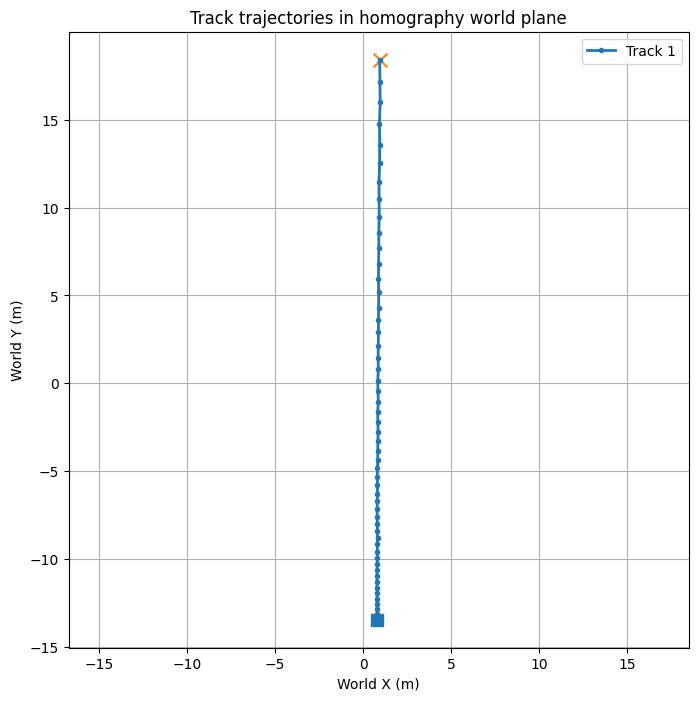

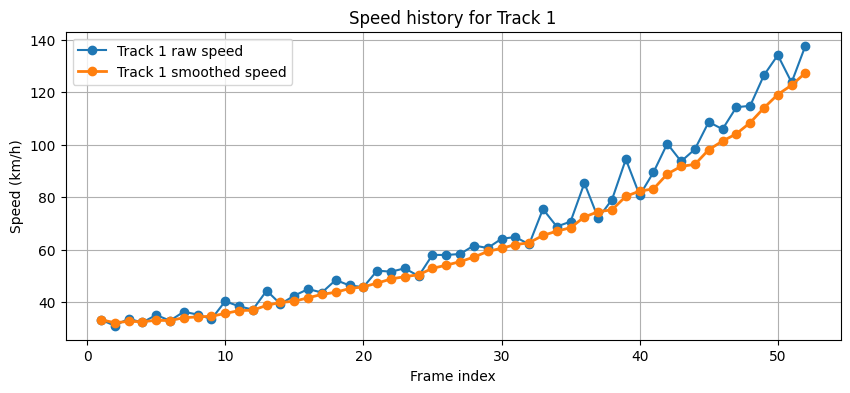


=== Track trajectory summaries ===

Track 1
  class_id              : 3
  num_points            : 53
  total_distance_m      : 31.855
  first_world_point     : [  0.7874656 -13.441859 ]
  last_world_point      : [ 0.9421652 18.405596 ]
  mean_raw_speed_kmh    : 66.161
  mean_smooth_speed_kmh : 62.355
  max_raw_speed_kmh     : 137.701
  max_smooth_speed_kmh  : 127.356


In [31]:
# ============================================================
# Cell 12: Inspect projected world trajectories and per-track speeds
# Purpose:
# - visualize each track in world-plane coordinates
# - inspect raw and smoothed speed histories
# - confirm that the homography-based motion is sensible
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

assert "TRACK_HISTORIES" in globals(), "Run Cell 11 first."

# -----------------------------
# 1) Choose which tracks to inspect
# -----------------------------
# By default, inspect all tracks that have at least 2 world points
TRACK_IDS_TO_INSPECT = [
    tid for tid, hist in TRACK_HISTORIES.items()
    if len(hist["world_points"]) >= 2
]

print("Tracks available for inspection:", TRACK_IDS_TO_INSPECT)

# -----------------------------
# 2) Plot world-plane trajectories
# -----------------------------
plt.figure(figsize=(8, 8))

for tid in TRACK_IDS_TO_INSPECT:
    hist = TRACK_HISTORIES[tid]
    world_pts = np.asarray(hist["world_points"], dtype=np.float32)

    if len(world_pts) < 2:
        continue

    xs = world_pts[:, 0]
    ys = world_pts[:, 1]

    plt.plot(xs, ys, marker="o", markersize=3, linewidth=2, label=f"Track {tid}")
    plt.scatter(xs[0], ys[0], s=80, marker="s")
    plt.scatter(xs[-1], ys[-1], s=100, marker="x")

plt.xlabel("World X (m)")
plt.ylabel("World Y (m)")
plt.title("Track trajectories in homography world plane")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# 3) Plot speed histories
# -----------------------------
for tid in TRACK_IDS_TO_INSPECT:
    hist = TRACK_HISTORIES[tid]

    frames = np.asarray(hist["frames"], dtype=np.int32)
    raw_speeds = hist["raw_speeds_kmh"]
    smooth_speeds = hist["smoothed_speeds_kmh"]

    raw_x = []
    raw_y = []
    smooth_x = []
    smooth_y = []

    for f, s in zip(frames, raw_speeds):
        if s is not None:
            raw_x.append(f)
            raw_y.append(float(s))

    for f, s in zip(frames, smooth_speeds):
        if s is not None:
            smooth_x.append(f)
            smooth_y.append(float(s))

    plt.figure(figsize=(10, 4))
    if len(raw_x) > 0:
        plt.plot(raw_x, raw_y, marker="o", linewidth=1.5, label=f"Track {tid} raw speed")
    if len(smooth_x) > 0:
        plt.plot(smooth_x, smooth_y, marker="o", linewidth=2, label=f"Track {tid} smoothed speed")

    plt.xlabel("Frame index")
    plt.ylabel("Speed (km/h)")
    plt.title(f"Speed history for Track {tid}")
    plt.grid(True)
    plt.legend()
    plt.show()

# -----------------------------
# 4) Print compact numeric summaries
# -----------------------------
print("\n=== Track trajectory summaries ===")
for tid in TRACK_IDS_TO_INSPECT:
    hist = TRACK_HISTORIES[tid]
    world_pts = np.asarray(hist["world_points"], dtype=np.float32)

    total_distance_m = 0.0
    if len(world_pts) >= 2:
        diffs = world_pts[1:] - world_pts[:-1]
        step_dists = np.linalg.norm(diffs, axis=1)
        total_distance_m = float(step_dists.sum())

    valid_raw = [float(s) for s in hist["raw_speeds_kmh"] if s is not None]
    valid_smooth = [float(s) for s in hist["smoothed_speeds_kmh"] if s is not None]

    print(f"\nTrack {tid}")
    print(f"  class_id              : {hist['class_id']}")
    print(f"  num_points            : {len(hist['world_points'])}")
    print(f"  total_distance_m      : {total_distance_m:.3f}")
    print(f"  first_world_point     : {world_pts[0] if len(world_pts) > 0 else None}")
    print(f"  last_world_point      : {world_pts[-1] if len(world_pts) > 0 else None}")
    print(f"  mean_raw_speed_kmh    : {np.mean(valid_raw):.3f}" if len(valid_raw) > 0 else "  mean_raw_speed_kmh    : None")
    print(f"  mean_smooth_speed_kmh : {np.mean(valid_smooth):.3f}" if len(valid_smooth) > 0 else "  mean_smooth_speed_kmh : None")
    print(f"  max_raw_speed_kmh     : {np.max(valid_raw):.3f}" if len(valid_raw) > 0 else "  max_raw_speed_kmh     : None")
    print(f"  max_smooth_speed_kmh  : {np.max(valid_smooth):.3f}" if len(valid_smooth) > 0 else "  max_smooth_speed_kmh  : None")

=== Cell 13: Windowed Speeds Computed ===
WINDOW_SPEED_FRAME_GAP  : 5
WINDOW_SPEED_SMOOTHING  : 5

Track 1
  original mean smoothed speed (km/h): 62.355
  windowed mean smoothed speed (km/h): 61.076
  original max raw speed (km/h)      : 137.701
  windowed max raw speed (km/h)      : 127.339
  latest windowed smoothed speed     : 118.2825521850586



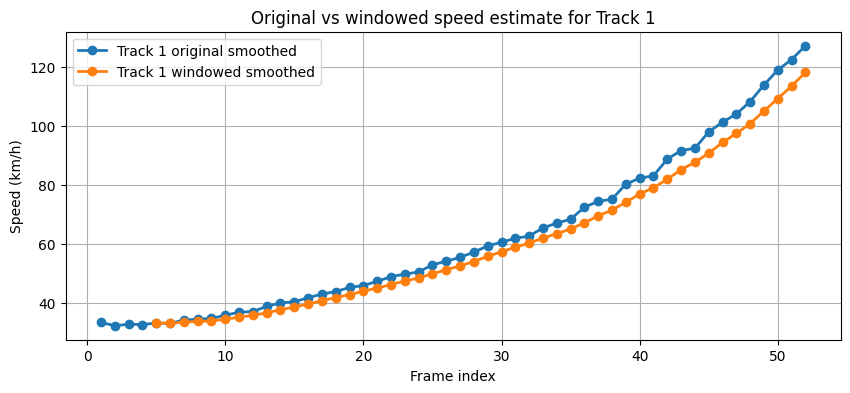

In [32]:
# ============================================================
# Cell 13: Compute more stable windowed speeds
# Purpose:
# - reduce frame-to-frame jitter by computing speed over a wider window
# - store windowed raw and smoothed speeds per track
# - prepare more reliable values for display in later cells
# ============================================================

import numpy as np

assert "TRACK_HISTORIES" in globals(), "Run Cell 11 first."

# -----------------------------
# 1) Configuration
# -----------------------------
# Instead of using only consecutive frames, compute speed using a wider gap.
# Example: compare point at frame t with point at frame t-5.
WINDOW_SPEED_FRAME_GAP = 5

# Optional second-stage smoothing on the windowed speeds
WINDOW_SPEED_SMOOTHING = 5

# Keep conservative physical guardrails
WINDOW_MAX_REASONABLE_SPEED_KMH = 200.0
WINDOW_MIN_REASONABLE_SPEED_KMH = 0.0

# -----------------------------
# 2) Helper functions
# -----------------------------
def compute_windowed_speeds_for_history(
    track_history,
    frame_gap=WINDOW_SPEED_FRAME_GAP,
    smoothing_window=WINDOW_SPEED_SMOOTHING,
    fps=30.0,
    min_kmh=WINDOW_MIN_REASONABLE_SPEED_KMH,
    max_kmh=WINDOW_MAX_REASONABLE_SPEED_KMH,
):
    """
    Compute speed using points separated by `frame_gap` observations.

    Adds / overwrites:
      - track_history["windowed_raw_speeds_kmh"]
      - track_history["windowed_smoothed_speeds_kmh"]
    """
    frames = track_history["frames"]
    world_points = track_history["world_points"]

    n = len(world_points)
    raw_windowed = [None] * n

    for i in range(n):
        j = i - int(frame_gap)
        if j < 0:
            continue

        p1 = world_points[j]
        p2 = world_points[i]
        f1 = frames[j]
        f2 = frames[i]
        frame_delta = f2 - f1

        speed_kmh = speed_kmh_from_positions(p1, p2, frame_delta, fps)

        if speed_kmh is not None:
            if not (float(min_kmh) <= float(speed_kmh) <= float(max_kmh)):
                speed_kmh = None

        raw_windowed[i] = speed_kmh

    smoothed_windowed = []
    for i in range(n):
        prefix = raw_windowed[: i + 1]
        smoothed_windowed.append(moving_average(prefix, window=smoothing_window))

    track_history["windowed_raw_speeds_kmh"] = raw_windowed
    track_history["windowed_smoothed_speeds_kmh"] = smoothed_windowed
    track_history["window_speed_frame_gap"] = int(frame_gap)
    track_history["window_speed_smoothing"] = int(smoothing_window)

    return track_history

def latest_windowed_speed_kmh(track_history, smoothed=True):
    key = "windowed_smoothed_speeds_kmh" if smoothed else "windowed_raw_speeds_kmh"
    if key not in track_history or len(track_history[key]) == 0:
        return None
    return track_history[key][-1]

# -----------------------------
# 3) Compute for all current tracks
# -----------------------------
for tid, hist in TRACK_HISTORIES.items():
    compute_windowed_speeds_for_history(
        track_history=hist,
        frame_gap=WINDOW_SPEED_FRAME_GAP,
        smoothing_window=WINDOW_SPEED_SMOOTHING,
        fps=fps,
        min_kmh=WINDOW_MIN_REASONABLE_SPEED_KMH,
        max_kmh=WINDOW_MAX_REASONABLE_SPEED_KMH,
    )

# -----------------------------
# 4) Compare original vs windowed speeds
# -----------------------------
print("=== Cell 13: Windowed Speeds Computed ===")
print("WINDOW_SPEED_FRAME_GAP  :", WINDOW_SPEED_FRAME_GAP)
print("WINDOW_SPEED_SMOOTHING  :", WINDOW_SPEED_SMOOTHING)
print("")

for tid, hist in TRACK_HISTORIES.items():
    raw_old = [float(s) for s in hist["raw_speeds_kmh"] if s is not None]
    smooth_old = [float(s) for s in hist["smoothed_speeds_kmh"] if s is not None]

    raw_new = [float(s) for s in hist["windowed_raw_speeds_kmh"] if s is not None]
    smooth_new = [float(s) for s in hist["windowed_smoothed_speeds_kmh"] if s is not None]

    print(f"Track {tid}")
    print(f"  original mean smoothed speed (km/h): {np.mean(smooth_old):.3f}" if len(smooth_old) > 0 else "  original mean smoothed speed (km/h): None")
    print(f"  windowed mean smoothed speed (km/h): {np.mean(smooth_new):.3f}" if len(smooth_new) > 0 else "  windowed mean smoothed speed (km/h): None")
    print(f"  original max raw speed (km/h)      : {np.max(raw_old):.3f}" if len(raw_old) > 0 else "  original max raw speed (km/h)      : None")
    print(f"  windowed max raw speed (km/h)      : {np.max(raw_new):.3f}" if len(raw_new) > 0 else "  windowed max raw speed (km/h)      : None")
    print(f"  latest windowed smoothed speed     : {latest_windowed_speed_kmh(hist, smoothed=True)}")
    print("")

# -----------------------------
# 5) Plot comparison for inspectable tracks
# -----------------------------
TRACK_IDS_TO_COMPARE = [
    tid for tid, hist in TRACK_HISTORIES.items()
    if len(hist["world_points"]) >= (WINDOW_SPEED_FRAME_GAP + 1)
]

for tid in TRACK_IDS_TO_COMPARE:
    hist = TRACK_HISTORIES[tid]
    frames_arr = np.asarray(hist["frames"], dtype=np.int32)

    orig_smooth_x, orig_smooth_y = [], []
    win_smooth_x, win_smooth_y = [], []

    for f, s in zip(frames_arr, hist["smoothed_speeds_kmh"]):
        if s is not None:
            orig_smooth_x.append(f)
            orig_smooth_y.append(float(s))

    for f, s in zip(frames_arr, hist["windowed_smoothed_speeds_kmh"]):
        if s is not None:
            win_smooth_x.append(f)
            win_smooth_y.append(float(s))

    plt.figure(figsize=(10, 4))
    if len(orig_smooth_x) > 0:
        plt.plot(orig_smooth_x, orig_smooth_y, marker="o", linewidth=2, label=f"Track {tid} original smoothed")
    if len(win_smooth_x) > 0:
        plt.plot(win_smooth_x, win_smooth_y, marker="o", linewidth=2, label=f"Track {tid} windowed smoothed")

    plt.xlabel("Frame index")
    plt.ylabel("Speed (km/h)")
    plt.title(f"Original vs windowed speed estimate for Track {tid}")
    plt.grid(True)
    plt.legend()
    plt.show()

=== Cell 14: Final Stabilized Speeds ===
FINAL_MIN_OBSERVATIONS   : 10
FINAL_USE_WINDOWED_SPEED : True
FINAL_MAX_SPEED_KMH      : 130.0
FINAL_MAX_STEP_CHANGE    : 12.0
FINAL_HOLD_LAST_VALID    : True
FINAL_SMOOTHING_WINDOW   : 7

Track 1
  base count                 : 48
  filtered count             : 44
  final count                : 44
  latest final speed         : 105.6148795427595
  mean final speed (km/h)    : 58.381
  max final speed (km/h)     : 105.615



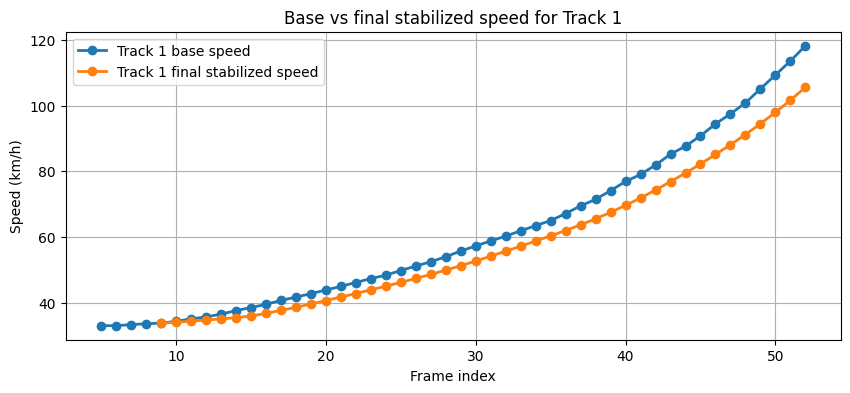

In [33]:
# ============================================================
# Cell 14: Build final stabilized speed estimates
# Purpose:
# - combine filtering rules with the windowed speed estimates
# - reject unstable jumps
# - suppress early unreliable values
# - create a final speed series for later video overlay
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

assert "TRACK_HISTORIES" in globals(), "Run Cell 11 first."
assert "latest_windowed_speed_kmh" in globals(), "Run Cell 13 first."

# -----------------------------
# 1) Final stabilization settings
# -----------------------------
FINAL_MIN_OBSERVATIONS = 10              # do not trust very early track estimates
FINAL_USE_WINDOWED_SPEED = True          # use Cell 13 speeds as base
FINAL_MAX_SPEED_KMH = 130.0              # stricter physical ceiling
FINAL_MAX_STEP_CHANGE_KMH = 12.0         # max allowed jump between adjacent displayed values
FINAL_HOLD_LAST_VALID = True             # keep last valid speed during brief instability
FINAL_SMOOTHING_WINDOW = 7               # second-stage smoothing for final display

# -----------------------------
# 2) Helper: choose base speed series
# -----------------------------
def get_base_speed_series(track_history, use_windowed=True):
    if use_windowed and "windowed_smoothed_speeds_kmh" in track_history:
        return list(track_history["windowed_smoothed_speeds_kmh"])
    return list(track_history["smoothed_speeds_kmh"])

# -----------------------------
# 3) Helper: final stabilization pass
# -----------------------------
def build_final_speed_series(
    track_history,
    min_observations=FINAL_MIN_OBSERVATIONS,
    use_windowed=FINAL_USE_WINDOWED_SPEED,
    max_speed_kmh=FINAL_MAX_SPEED_KMH,
    max_step_change_kmh=FINAL_MAX_STEP_CHANGE_KMH,
    hold_last_valid=FINAL_HOLD_LAST_VALID,
    smoothing_window=FINAL_SMOOTHING_WINDOW,
):
    """
    Build a conservative final speed series for display/use.

    Rules:
    - ignore first few observations
    - reject None or over-max values
    - reject sudden adjacent jumps larger than max_step_change_kmh
    - optionally hold the last valid speed through a rejected frame
    - apply a final trailing moving average
    """
    base_series = get_base_speed_series(track_history, use_windowed=use_windowed)
    n = len(base_series)

    filtered = [None] * n
    last_valid = None

    for i, s in enumerate(base_series):
        # Not enough observations yet
        if i + 1 < int(min_observations):
            filtered[i] = None
            continue

        # Missing value
        if s is None:
            filtered[i] = last_valid if hold_last_valid else None
            continue

        s = float(s)

        # Hard ceiling
        if s < 0.0 or s > float(max_speed_kmh):
            filtered[i] = last_valid if hold_last_valid else None
            continue

        # Sudden jump check
        if last_valid is not None:
            if abs(s - last_valid) > float(max_step_change_kmh):
                filtered[i] = last_valid if hold_last_valid else None
                continue

        filtered[i] = s
        last_valid = filtered[i]

    # Final smoothing
    final_smoothed = []
    for i in range(n):
        prefix = filtered[: i + 1]
        final_smoothed.append(moving_average(prefix, window=smoothing_window))

    track_history["final_filtered_speeds_kmh"] = filtered
    track_history["final_display_speeds_kmh"] = final_smoothed
    track_history["final_speed_config"] = {
        "min_observations": int(min_observations),
        "use_windowed": bool(use_windowed),
        "max_speed_kmh": float(max_speed_kmh),
        "max_step_change_kmh": float(max_step_change_kmh),
        "hold_last_valid": bool(hold_last_valid),
        "smoothing_window": int(smoothing_window),
    }

    return track_history

def latest_final_speed_kmh(track_history):
    series = track_history.get("final_display_speeds_kmh", [])
    if len(series) == 0:
        return None
    return series[-1]

# -----------------------------
# 4) Apply to all tracks
# -----------------------------
for tid, hist in TRACK_HISTORIES.items():
    build_final_speed_series(hist)

# -----------------------------
# 5) Print summary
# -----------------------------
print("=== Cell 14: Final Stabilized Speeds ===")
print("FINAL_MIN_OBSERVATIONS   :", FINAL_MIN_OBSERVATIONS)
print("FINAL_USE_WINDOWED_SPEED :", FINAL_USE_WINDOWED_SPEED)
print("FINAL_MAX_SPEED_KMH      :", FINAL_MAX_SPEED_KMH)
print("FINAL_MAX_STEP_CHANGE    :", FINAL_MAX_STEP_CHANGE_KMH)
print("FINAL_HOLD_LAST_VALID    :", FINAL_HOLD_LAST_VALID)
print("FINAL_SMOOTHING_WINDOW   :", FINAL_SMOOTHING_WINDOW)
print("")

for tid, hist in TRACK_HISTORIES.items():
    final_vals = [float(s) for s in hist.get("final_display_speeds_kmh", []) if s is not None]
    filtered_vals = [float(s) for s in hist.get("final_filtered_speeds_kmh", []) if s is not None]
    base_vals = [float(s) for s in get_base_speed_series(hist, use_windowed=FINAL_USE_WINDOWED_SPEED) if s is not None]

    print(f"Track {tid}")
    print(f"  base count                 : {len(base_vals)}")
    print(f"  filtered count             : {len(filtered_vals)}")
    print(f"  final count                : {len(final_vals)}")
    print(f"  latest final speed         : {latest_final_speed_kmh(hist)}")
    print(f"  mean final speed (km/h)    : {np.mean(final_vals):.3f}" if len(final_vals) > 0 else "  mean final speed (km/h)    : None")
    print(f"  max final speed (km/h)     : {np.max(final_vals):.3f}" if len(final_vals) > 0 else "  max final speed (km/h)     : None")
    print("")

# -----------------------------
# 6) Plot base vs final display speeds
# -----------------------------
TRACK_IDS_TO_PLOT = [
    tid for tid, hist in TRACK_HISTORIES.items()
    if len(hist["frames"]) >= FINAL_MIN_OBSERVATIONS
]

for tid in TRACK_IDS_TO_PLOT:
    hist = TRACK_HISTORIES[tid]
    frames_arr = np.asarray(hist["frames"], dtype=np.int32)

    base_series = get_base_speed_series(hist, use_windowed=FINAL_USE_WINDOWED_SPEED)
    final_series = hist.get("final_display_speeds_kmh", [])

    base_x, base_y = [], []
    final_x, final_y = [], []

    for f, s in zip(frames_arr, base_series):
        if s is not None:
            base_x.append(f)
            base_y.append(float(s))

    for f, s in zip(frames_arr, final_series):
        if s is not None:
            final_x.append(f)
            final_y.append(float(s))

    plt.figure(figsize=(10, 4))
    if len(base_x) > 0:
        plt.plot(base_x, base_y, marker="o", linewidth=2, label=f"Track {tid} base speed")
    if len(final_x) > 0:
        plt.plot(final_x, final_y, marker="o", linewidth=2, label=f"Track {tid} final stabilized speed")

    plt.xlabel("Frame index")
    plt.ylabel("Speed (km/h)")
    plt.title(f"Base vs final stabilized speed for Track {tid}")
    plt.grid(True)
    plt.legend()
    plt.show()

In [35]:
# ============================================================
# Cell 15: Create final annotated video with stabilized speeds
# Purpose:
# - rerun detection + tracking one more time
# - use the representative point logic from Cell 9
# - mark border-touching boxes
# - overlay final stabilized speed for each eligible track
# - save the tracked + speed-estimated output video
# ============================================================

from pathlib import Path
import cv2
import numpy as np
from tqdm.auto import tqdm

assert "TRACK_HISTORIES" in globals(), "Run Cells 11-14 first."
assert "latest_final_speed_kmh" in globals(), "Run Cell 14 first."
assert "representative_point_xyxy" in globals(), "Run updated Cell 9 first."
assert "bbox_touches_border" in globals(), "Run updated Cell 9 first."

# -----------------------------
# 1) Input / output configuration
# -----------------------------
VIDEO_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "single_average_passenger_car.mp4"
OUTPUT_PATH_CELL15 = Path(PHASE_ROOT) / "rfdetr" / "videos" / "tracked_with_final_speeds.mp4"

DETECT_EVERY_N = 1
DET_THRESHOLD  = 0.30
MIN_BOX_AREA   = 30 * 30

FPS = 30.0
CLASS_MAP = PHASE_CLASSES

# Display configuration
SHOW_TRAIL = True
TRAIL_LENGTH = 20
SHOW_REPRESENTATIVE_POINT = True
SHOW_BORDER_STATUS = True
SHOW_SPEED_ONLY_WHEN_READY = True
SPEED_DECIMALS = 1

assert VIDEO_PATH is not None, "Provide VIDEO_PATH."

# -----------------------------
# 2) Build video reader
# -----------------------------
cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"

fps = cap.get(cv2.CAP_PROP_FPS)
if fps is None or fps <= 1:
    fps = FPS

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("Input:", VIDEO_PATH)
print(f"Frames: {total_frames} | Size: {width}x{height} | FPS: {fps}")
print("Representative point mode:", REPRESENTATIVE_POINT_MODE)
print("Border margin (px):", BORDER_MARGIN_PX)

# -----------------------------
# 3) Reset tracker for fresh replay
# -----------------------------
try:
    if hasattr(TRACKER, "frame_rate"):
        TRACKER.frame_rate = int(round(fps))
except Exception:
    pass

if hasattr(TRACKER, "reset"):
    TRACKER.reset()

track_meta = {}

# -----------------------------
# 4) Helpers reused from earlier cells
# -----------------------------
def build_tensors_from_detections(detections: "sv.Detections") -> np.ndarray:
    if len(detections) == 0:
        return np.zeros((0, 5), dtype=np.float32)
    return np.hstack([
        detections.xyxy.astype(np.float32),
        detections.confidence.reshape(-1, 1).astype(np.float32),
    ])

def active_tracks_to_boxes_and_ids(tracker) -> tuple[list[np.ndarray], list[int]]:
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

# -----------------------------
# 5) Output writer
# -----------------------------
OUTPUT_PATH_CELL15.parent.mkdir(parents=True, exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_PATH_CELL15), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not open writer: {OUTPUT_PATH_CELL15}"

# -----------------------------
# 6) Main loop
# -----------------------------
pbar = tqdm(total=total_frames, desc="Cell 15: writing final speed video")

for frame_idx in range(total_frames):
    ok, frame_bgr = cap.read()
    if not ok:
        break

    # Detection frame?
    if frame_idx % DETECT_EVERY_N == 0:
        temp_path = "temp_frame.jpg"
        cv2.imwrite(temp_path, frame_bgr)

        det = DETECTOR.predict(temp_path, threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        # Filter tiny boxes
        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        tensors = build_tensors_from_detections(detections)
        _ = TRACKER.update_with_tensors(tensors)

        det_with_ids = TRACKER.update_with_detections(detections)
        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                track_meta[tid] = (cls, conf)
    else:
        _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

    out = frame_bgr.copy()
    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)

    for box, tid in zip(boxes, ids):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls, conf = track_meta.get(tid, (-1, 0.0))
        label = CLASS_MAP.get(cls, f"class_{cls}") if cls != -1 else "unknown"

        touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)

        # Draw bbox with color based on border status
        box_color = (0, 165, 255) if touches_border else (0, 255, 0)
        cv2.rectangle(out, (x1, y1), (x2, y2), box_color, 2)

        # Representative point
        rep_pt = representative_point_xyxy(box, mode=REPRESENTATIVE_POINT_MODE)
        rep_x, rep_y = map(int, np.round(rep_pt))

        if SHOW_REPRESENTATIVE_POINT:
            cv2.circle(out, (rep_x, rep_y), 4, (0, 0, 255), -1)

        # Optional trajectory trail from stored history
        if SHOW_TRAIL and tid in TRACK_HISTORIES:
            pts = np.asarray(TRACK_HISTORIES[tid]["image_points"], dtype=np.float32)
            if len(pts) >= 2:
                pts = np.round(pts[-TRAIL_LENGTH:]).astype(int)
                for j in range(1, len(pts)):
                    cv2.line(out, tuple(pts[j - 1]), tuple(pts[j]), (255, 0, 0), 2, cv2.LINE_AA)

        # Pull final stabilized speed from stored history
        speed_text = None
        if tid in TRACK_HISTORIES:
            hist = TRACK_HISTORIES[tid]

            # Speed histories are indexed by observation count, not raw frame index.
            # Find the observation corresponding to this frame if it exists.
            if "frames" in hist and "final_display_speeds_kmh" in hist:
                try:
                    obs_idx = hist["frames"].index(frame_idx)
                    speed_val = hist["final_display_speeds_kmh"][obs_idx]
                except ValueError:
                    speed_val = None
            else:
                speed_val = None

            if speed_val is not None:
                speed_text = f"{speed_val:.{SPEED_DECIMALS}f} km/h"

        # Compose label text
        text = f"ID {tid}: {label}"
        if conf is not None:
            text += f" {conf:.2f}"

        if SHOW_BORDER_STATUS:
            text += " | BORDER" if touches_border else " | OK"

        if speed_text is not None:
            text += f" | {speed_text}"
        elif not SHOW_SPEED_ONLY_WHEN_READY:
            text += " | speed: --"

        cv2.putText(
            out,
            text,
            (x1, max(0, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            box_color,
            1,
            cv2.LINE_AA,
        )

    writer.write(out)
    pbar.update(1)

pbar.close()
cap.release()
writer.release()

print(f"\nDone. Saved final annotated video to: {OUTPUT_PATH_CELL15}")

Input: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\single_average_passenger_car.mp4
Frames: 64 | Size: 898x506 | FPS: 30.0
Representative point mode: center
Border margin (px): 20


Cell 15: writing final speed video:   0%|          | 0/64 [00:00<?, ?it/s]


Done. Saved final annotated video to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\tracked_with_final_speeds.mp4


In [36]:
# ============================================================
# Cell 16: Save and load calibration artifacts
# Purpose:
# - persist calibration so you do not have to click points every run
# - save image points, world points, homography, and metadata
# - reload calibration later for the same camera/setup
# ============================================================

from pathlib import Path
import json
import numpy as np

assert "REFERENCE_VEHICLE_IMAGE_POINTS" in globals(), "Run Cells 6-8 first."
assert "REFERENCE_VEHICLE_WORLD_POINTS" in globals(), "Run Cells 7-8 first."
assert "HOMOGRAPHY_IMG_TO_WORLD" in globals(), "Run Cell 8 first."
assert "HOMOGRAPHY_WORLD_TO_IMG" in globals(), "Run Cell 8 first."

# -----------------------------
# 1) Configuration
# -----------------------------
CALIBRATION_NAME = "single_average_passenger_car_bev"
CALIBRATION_DIR = Path(PHASE_ROOT) / "rfdetr" / "calibration"
CALIBRATION_DIR.mkdir(parents=True, exist_ok=True)

CALIBRATION_JSON_PATH = CALIBRATION_DIR / f"{CALIBRATION_NAME}.json"
CALIBRATION_NPZ_PATH  = CALIBRATION_DIR / f"{CALIBRATION_NAME}.npz"

# Choose action:
#   "save" -> save current calibration from notebook state
#   "load" -> load existing calibration from disk into notebook state
CALIBRATION_ACTION = "save"

# -----------------------------
# 2) Helpers
# -----------------------------
def _to_serializable_array(arr):
    return np.asarray(arr).tolist()

def save_calibration_artifacts(
    json_path,
    npz_path,
    calibration_name,
    image_points,
    world_points,
    H_img_to_world,
    H_world_to_img,
    vehicle_dimensions=None,
    extra_metadata=None,
):
    image_points = np.asarray(image_points, dtype=np.float32)
    world_points = np.asarray(world_points, dtype=np.float32)
    H_img_to_world = np.asarray(H_img_to_world, dtype=np.float64)
    H_world_to_img = np.asarray(H_world_to_img, dtype=np.float64)

    metadata = {
        "calibration_name": calibration_name,
        "image_points": _to_serializable_array(image_points),
        "world_points": _to_serializable_array(world_points),
        "H_img_to_world": _to_serializable_array(H_img_to_world),
        "H_world_to_img": _to_serializable_array(H_world_to_img),
        "vehicle_dimensions": vehicle_dimensions if vehicle_dimensions is not None else {},
        "extra_metadata": extra_metadata if extra_metadata is not None else {},
    }

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    np.savez(
        npz_path,
        image_points=image_points,
        world_points=world_points,
        H_img_to_world=H_img_to_world,
        H_world_to_img=H_world_to_img,
    )

def load_calibration_artifacts(json_path, npz_path=None):
    with open(json_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    loaded = {
        "calibration_name": metadata.get("calibration_name", None),
        "image_points": np.asarray(metadata["image_points"], dtype=np.float32),
        "world_points": np.asarray(metadata["world_points"], dtype=np.float32),
        "H_img_to_world": np.asarray(metadata["H_img_to_world"], dtype=np.float64),
        "H_world_to_img": np.asarray(metadata["H_world_to_img"], dtype=np.float64),
        "vehicle_dimensions": metadata.get("vehicle_dimensions", {}),
        "extra_metadata": metadata.get("extra_metadata", {}),
    }

    # Optional consistency check against NPZ
    if npz_path is not None and Path(npz_path).exists():
        npz = np.load(npz_path)
        for k_json, k_npz in [
            ("image_points", "image_points"),
            ("world_points", "world_points"),
            ("H_img_to_world", "H_img_to_world"),
            ("H_world_to_img", "H_world_to_img"),
        ]:
            a = loaded[k_json]
            b = np.asarray(npz[k_npz])
            if not np.allclose(a, b, atol=1e-6):
                print(f"Warning: mismatch between JSON and NPZ for {k_json}")

    return loaded

# -----------------------------
# 3) Save or load
# -----------------------------
if CALIBRATION_ACTION == "save":
    extra_metadata = {
        "calibration_frame_idx": int(CALIBRATION_FRAME_IDX) if "CALIBRATION_FRAME_IDX" in globals() else None,
        "representative_point_mode_at_save": globals().get("REPRESENTATIVE_POINT_MODE", None),
    }

    save_calibration_artifacts(
        json_path=CALIBRATION_JSON_PATH,
        npz_path=CALIBRATION_NPZ_PATH,
        calibration_name=CALIBRATION_NAME,
        image_points=REFERENCE_VEHICLE_IMAGE_POINTS,
        world_points=REFERENCE_VEHICLE_WORLD_POINTS,
        H_img_to_world=HOMOGRAPHY_IMG_TO_WORLD,
        H_world_to_img=HOMOGRAPHY_WORLD_TO_IMG,
        vehicle_dimensions=globals().get("REFERENCE_VEHICLE_DIMENSIONS", {}),
        extra_metadata=extra_metadata,
    )

    print("=== Cell 16: Calibration Saved ===")
    print("Calibration name :", CALIBRATION_NAME)
    print("JSON path        :", CALIBRATION_JSON_PATH)
    print("NPZ path         :", CALIBRATION_NPZ_PATH)
    print("==================================")

elif CALIBRATION_ACTION == "load":
    assert CALIBRATION_JSON_PATH.exists(), f"Calibration JSON not found: {CALIBRATION_JSON_PATH}"

    loaded = load_calibration_artifacts(CALIBRATION_JSON_PATH, CALIBRATION_NPZ_PATH)

    # Restore into notebook globals so later cells can reuse them
    REFERENCE_VEHICLE_IMAGE_POINTS = loaded["image_points"]
    REFERENCE_VEHICLE_WORLD_POINTS = loaded["world_points"]
    HOMOGRAPHY_IMG_TO_WORLD = loaded["H_img_to_world"]
    HOMOGRAPHY_WORLD_TO_IMG = loaded["H_world_to_img"]
    REFERENCE_VEHICLE_DIMENSIONS = loaded["vehicle_dimensions"]

    print("=== Cell 16: Calibration Loaded ===")
    print("Calibration name :", loaded["calibration_name"])
    print("JSON path        :", CALIBRATION_JSON_PATH)
    print("NPZ path         :", CALIBRATION_NPZ_PATH)
    print("")
    print("Restored variables:")
    print("  - REFERENCE_VEHICLE_IMAGE_POINTS")
    print("  - REFERENCE_VEHICLE_WORLD_POINTS")
    print("  - HOMOGRAPHY_IMG_TO_WORLD")
    print("  - HOMOGRAPHY_WORLD_TO_IMG")
    print("  - REFERENCE_VEHICLE_DIMENSIONS")
    print("===================================")

    print("\nLoaded image points:")
    for i, (x, y) in enumerate(REFERENCE_VEHICLE_IMAGE_POINTS, start=1):
        print(f"  Point {i}: ({x:.1f}, {y:.1f})")

    print("\nLoaded world points:")
    for i, (x, y) in enumerate(REFERENCE_VEHICLE_WORLD_POINTS, start=1):
        print(f"  Point {i}: ({x:.3f}, {y:.3f})")

else:
    raise ValueError("CALIBRATION_ACTION must be either 'save' or 'load'")

=== Cell 16: Calibration Saved ===
Calibration name : single_average_passenger_car_bev
JSON path        : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\calibration\single_average_passenger_car_bev.json
NPZ path         : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\calibration\single_average_passenger_car_bev.npz


In [37]:
# ============================================================
# Cell 17: Export track histories and run summaries
# Purpose:
# - save per-track / per-observation results to CSV
# - save compact track summary to JSON
# - make later analysis easier without re-running the notebook
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd

assert "TRACK_HISTORIES" in globals(), "Run Cells 11-14 first."

# -----------------------------
# 1) Output configuration
# -----------------------------
EXPORT_NAME = "single_average_passenger_car_bev_run"
EXPORT_DIR = Path(PHASE_ROOT) / "rfdetr" / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

TRACK_OBSERVATIONS_CSV_PATH = EXPORT_DIR / f"{EXPORT_NAME}_track_observations.csv"
TRACK_SUMMARY_JSON_PATH     = EXPORT_DIR / f"{EXPORT_NAME}_track_summary.json"
RUN_CONFIG_JSON_PATH        = EXPORT_DIR / f"{EXPORT_NAME}_run_config.json"

# -----------------------------
# 2) Helpers
# -----------------------------
def _safe_list_get(seq, idx, default=None):
    if seq is None:
        return default
    if idx < 0 or idx >= len(seq):
        return default
    return seq[idx]

def build_track_observations_dataframe(track_histories):
    """
    One row per stored observation.
    """
    rows = []

    for tid, hist in track_histories.items():
        frames = hist.get("frames", [])
        image_points = hist.get("image_points", [])
        world_points = hist.get("world_points", [])
        raw_speeds = hist.get("raw_speeds_kmh", [])
        smooth_speeds = hist.get("smoothed_speeds_kmh", [])
        windowed_raw = hist.get("windowed_raw_speeds_kmh", [])
        windowed_smooth = hist.get("windowed_smoothed_speeds_kmh", [])
        final_filtered = hist.get("final_filtered_speeds_kmh", [])
        final_display = hist.get("final_display_speeds_kmh", [])

        n = len(frames)

        for i in range(n):
            img_pt = _safe_list_get(image_points, i, default=[None, None])
            world_pt = _safe_list_get(world_points, i, default=[None, None])

            row = {
                "track_id": int(tid),
                "obs_index": int(i),
                "frame_idx": int(frames[i]),
                "class_id": hist.get("class_id", None),
                "confidence": hist.get("confidence", None),

                "image_x": float(img_pt[0]) if img_pt is not None else None,
                "image_y": float(img_pt[1]) if img_pt is not None else None,

                "world_x_m": float(world_pt[0]) if world_pt is not None else None,
                "world_y_m": float(world_pt[1]) if world_pt is not None else None,

                "raw_speed_kmh": _safe_list_get(raw_speeds, i, None),
                "smoothed_speed_kmh": _safe_list_get(smooth_speeds, i, None),
                "windowed_raw_speed_kmh": _safe_list_get(windowed_raw, i, None),
                "windowed_smoothed_speed_kmh": _safe_list_get(windowed_smooth, i, None),
                "final_filtered_speed_kmh": _safe_list_get(final_filtered, i, None),
                "final_display_speed_kmh": _safe_list_get(final_display, i, None),
            }
            rows.append(row)

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["track_id", "frame_idx", "obs_index"]).reset_index(drop=True)
    return df

def summarize_single_track(track_id, hist):
    """
    Compact summary dictionary for one track.
    """
    world_pts = np.asarray(hist.get("world_points", []), dtype=np.float32)
    frames = hist.get("frames", [])

    total_distance_m = 0.0
    if len(world_pts) >= 2:
        diffs = world_pts[1:] - world_pts[:-1]
        total_distance_m = float(np.linalg.norm(diffs, axis=1).sum())

    def valid_vals(key):
        return [float(v) for v in hist.get(key, []) if v is not None]

    raw_vals = valid_vals("raw_speeds_kmh")
    smooth_vals = valid_vals("smoothed_speeds_kmh")
    windowed_vals = valid_vals("windowed_smoothed_speeds_kmh")
    final_vals = valid_vals("final_display_speeds_kmh")

    summary = {
        "track_id": int(track_id),
        "class_id": hist.get("class_id", None),
        "confidence": hist.get("confidence", None),
        "num_observations": int(len(frames)),
        "first_frame": int(frames[0]) if len(frames) > 0 else None,
        "last_frame": int(frames[-1]) if len(frames) > 0 else None,
        "total_distance_m": total_distance_m,
        "first_world_point": world_pts[0].tolist() if len(world_pts) > 0 else None,
        "last_world_point": world_pts[-1].tolist() if len(world_pts) > 0 else None,

        "mean_raw_speed_kmh": float(np.mean(raw_vals)) if len(raw_vals) > 0 else None,
        "max_raw_speed_kmh": float(np.max(raw_vals)) if len(raw_vals) > 0 else None,

        "mean_smoothed_speed_kmh": float(np.mean(smooth_vals)) if len(smooth_vals) > 0 else None,
        "max_smoothed_speed_kmh": float(np.max(smooth_vals)) if len(smooth_vals) > 0 else None,

        "mean_windowed_smoothed_speed_kmh": float(np.mean(windowed_vals)) if len(windowed_vals) > 0 else None,
        "max_windowed_smoothed_speed_kmh": float(np.max(windowed_vals)) if len(windowed_vals) > 0 else None,

        "mean_final_display_speed_kmh": float(np.mean(final_vals)) if len(final_vals) > 0 else None,
        "max_final_display_speed_kmh": float(np.max(final_vals)) if len(final_vals) > 0 else None,
        "latest_final_display_speed_kmh": float(final_vals[-1]) if len(final_vals) > 0 else None,
    }
    return summary

def build_track_summary(track_histories):
    summaries = []
    for tid, hist in track_histories.items():
        summaries.append(summarize_single_track(tid, hist))
    summaries.sort(key=lambda x: x["track_id"])
    return summaries

# -----------------------------
# 3) Build exports
# -----------------------------
df_tracks = build_track_observations_dataframe(TRACK_HISTORIES)
track_summary = build_track_summary(TRACK_HISTORIES)

run_config = {
    "export_name": EXPORT_NAME,
    "representative_point_mode": globals().get("REPRESENTATIVE_POINT_MODE", None),
    "border_margin_px": globals().get("BORDER_MARGIN_PX", None),
    "default_speed_window": globals().get("DEFAULT_SPEED_WINDOW", None),
    "window_speed_frame_gap": globals().get("WINDOW_SPEED_FRAME_GAP", None),
    "window_speed_smoothing": globals().get("WINDOW_SPEED_SMOOTHING", None),
    "final_min_observations": globals().get("FINAL_MIN_OBSERVATIONS", None),
    "final_use_windowed_speed": globals().get("FINAL_USE_WINDOWED_SPEED", None),
    "final_max_speed_kmh": globals().get("FINAL_MAX_SPEED_KMH", None),
    "final_max_step_change_kmh": globals().get("FINAL_MAX_STEP_CHANGE_KMH", None),
    "final_hold_last_valid": globals().get("FINAL_HOLD_LAST_VALID", None),
    "final_smoothing_window": globals().get("FINAL_SMOOTHING_WINDOW", None),
    "reference_vehicle_dimensions": globals().get("REFERENCE_VEHICLE_DIMENSIONS", {}),
    "calibration_name": globals().get("CALIBRATION_NAME", None),
}

# -----------------------------
# 4) Save to disk
# -----------------------------
df_tracks.to_csv(TRACK_OBSERVATIONS_CSV_PATH, index=False)

with open(TRACK_SUMMARY_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(track_summary, f, indent=2)

with open(RUN_CONFIG_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=2)

# -----------------------------
# 5) Console summary
# -----------------------------
print("=== Cell 17: Exports Saved ===")
print("Track observations CSV :", TRACK_OBSERVATIONS_CSV_PATH)
print("Track summary JSON     :", TRACK_SUMMARY_JSON_PATH)
print("Run config JSON        :", RUN_CONFIG_JSON_PATH)
print("")

print(f"Number of exported observations : {len(df_tracks)}")
print(f"Number of exported tracks       : {len(track_summary)}")

if len(track_summary) > 0:
    print("\nTrack summaries:")
    for s in track_summary[:10]:
        print(
            f"  Track {s['track_id']} | "
            f"class={s['class_id']} | "
            f"obs={s['num_observations']} | "
            f"mean_final={s['mean_final_display_speed_kmh']}"
        )

print("================================")

=== Cell 17: Exports Saved ===
Track observations CSV : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\exports\single_average_passenger_car_bev_run_track_observations.csv
Track summary JSON     : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\exports\single_average_passenger_car_bev_run_track_summary.json
Run config JSON        : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\exports\single_average_passenger_car_bev_run_run_config.json

Number of exported observations : 53
Number of exported tracks       : 1

Track summaries:
  Track 1 | class=3 | obs=53 | mean_final=58.38075447320009


In [39]:
# ============================================================
# Cell 18: End-to-end runner for video OR frames directory
# Purpose:
# - provide one entry point for detection + tracking + speed estimation
# - support either a video path or a directory of frames
# - optionally use saved calibration
# - write final annotated output video
# - export track observations / summaries
# ============================================================

from pathlib import Path
import cv2
import json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

assert "DETECTOR" in globals(), "Run Cells 1-2 first."
assert "TRACKER" in globals(), "Run Cell 3 first."
assert "representative_point_xyxy" in globals(), "Run Cell 9 first."
assert "bbox_touches_border" in globals(), "Run Cell 9 first."
assert "get_or_create_track_history" in globals(), "Run Cell 10 first."
assert "mark_track_observed" in globals(), "Run Cell 10 first."
assert "update_missing_tracks" in globals(), "Run Cell 10 first."
assert "build_final_speed_series" in globals(), "Run Cell 14 first."

# -----------------------------
# 1) User configuration
# -----------------------------
INPUT_TYPE = "video"   # "video" or "frames"

VIDEO_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "custom_video.mp4"
FRAMES_DIR = None      # e.g. Path(PHASE_ROOT) / "rfdetr" / "videos" / "my_frames"

RUN_NAME = "custom_video_bev_e2e"
OUTPUT_DIR = Path(PHASE_ROOT) / "rfdetr" / "videos" / "speed-estimation-runs" / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_VIDEO_PATH = OUTPUT_DIR / f"{RUN_NAME}_annotated.mp4"
OUTPUT_TRACK_CSV_PATH = OUTPUT_DIR / f"{RUN_NAME}_track_observations.csv"
OUTPUT_TRACK_SUMMARY_JSON_PATH = OUTPUT_DIR / f"{RUN_NAME}_track_summary.json"
OUTPUT_RUN_CONFIG_JSON_PATH = OUTPUT_DIR / f"{RUN_NAME}_run_config.json"

# Detection / tracking settings
DETECT_EVERY_N = 1
DET_THRESHOLD = 0.30
MIN_BOX_AREA = 30 * 30
FPS_FALLBACK = 30.0
CLASS_MAP = PHASE_CLASSES

# Display settings
SHOW_TRAIL = True
TRAIL_LENGTH = 20
SHOW_REPRESENTATIVE_POINT = True
SHOW_BORDER_STATUS = True
SHOW_SPEED_ONLY_WHEN_READY = True
SPEED_DECIMALS = 1

# If you have multiple saved calibrations, load the right one before running this cell.
# This cell assumes HOMOGRAPHY_* variables already exist in memory.

# -----------------------------
# 2) Input helpers
# -----------------------------
def list_frames(folder: Path):
    exts = (".jpg", ".jpeg", ".png")
    frames = [p for p in folder.iterdir() if p.suffix.lower() in exts]
    return sorted(frames, key=lambda p: p.name)

def open_input_source(input_type, video_path=None, frames_dir=None, fps_fallback=30.0):
    if input_type == "video":
        assert video_path is not None, "VIDEO_PATH must be provided when INPUT_TYPE='video'"
        cap = cv2.VideoCapture(str(video_path))
        assert cap.isOpened(), f"Could not open video: {video_path}"

        fps = cap.get(cv2.CAP_PROP_FPS)
        if fps is None or fps <= 1:
            fps = fps_fallback

        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        return {
            "mode": "video",
            "cap": cap,
            "frames_list": None,
            "fps": fps,
            "width": width,
            "height": height,
            "total_frames": total_frames,
            "source_text": str(video_path),
        }

    elif input_type == "frames":
        assert frames_dir is not None, "FRAMES_DIR must be provided when INPUT_TYPE='frames'"
        frames_list = list_frames(frames_dir)
        assert len(frames_list) > 0, f"No frames found in: {frames_dir}"

        first = cv2.imread(str(frames_list[0]))
        assert first is not None, f"Could not read first frame: {frames_list[0]}"
        height, width = first.shape[:2]

        return {
            "mode": "frames",
            "cap": None,
            "frames_list": frames_list,
            "fps": fps_fallback,
            "width": width,
            "height": height,
            "total_frames": len(frames_list),
            "source_text": str(frames_dir),
        }

    else:
        raise ValueError("INPUT_TYPE must be either 'video' or 'frames'")

def read_frame_from_source(source, frame_idx):
    if source["mode"] == "video":
        ok, frame_bgr = source["cap"].read()
        if not ok:
            return None
        return frame_bgr
    else:
        frame_path = source["frames_list"][frame_idx]
        frame_bgr = cv2.imread(str(frame_path))
        return frame_bgr

# -----------------------------
# 3) Export helpers
# -----------------------------
def _safe_list_get(seq, idx, default=None):
    if seq is None:
        return default
    if idx < 0 or idx >= len(seq):
        return default
    return seq[idx]

def build_track_observations_dataframe(track_histories):
    rows = []

    for tid, hist in track_histories.items():
        frames = hist.get("frames", [])
        image_points = hist.get("image_points", [])
        world_points = hist.get("world_points", [])
        raw_speeds = hist.get("raw_speeds_kmh", [])
        smooth_speeds = hist.get("smoothed_speeds_kmh", [])
        windowed_raw = hist.get("windowed_raw_speeds_kmh", [])
        windowed_smooth = hist.get("windowed_smoothed_speeds_kmh", [])
        final_filtered = hist.get("final_filtered_speeds_kmh", [])
        final_display = hist.get("final_display_speeds_kmh", [])

        n = len(frames)

        for i in range(n):
            img_pt = _safe_list_get(image_points, i, default=[None, None])
            world_pt = _safe_list_get(world_points, i, default=[None, None])

            rows.append({
                "track_id": int(tid),
                "obs_index": int(i),
                "frame_idx": int(frames[i]),
                "class_id": hist.get("class_id", None),
                "confidence": hist.get("confidence", None),
                "image_x": float(img_pt[0]) if img_pt is not None else None,
                "image_y": float(img_pt[1]) if img_pt is not None else None,
                "world_x_m": float(world_pt[0]) if world_pt is not None else None,
                "world_y_m": float(world_pt[1]) if world_pt is not None else None,
                "raw_speed_kmh": _safe_list_get(raw_speeds, i, None),
                "smoothed_speed_kmh": _safe_list_get(smooth_speeds, i, None),
                "windowed_raw_speed_kmh": _safe_list_get(windowed_raw, i, None),
                "windowed_smoothed_speed_kmh": _safe_list_get(windowed_smooth, i, None),
                "final_filtered_speed_kmh": _safe_list_get(final_filtered, i, None),
                "final_display_speed_kmh": _safe_list_get(final_display, i, None),
            })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["track_id", "frame_idx", "obs_index"]).reset_index(drop=True)
    return df

def summarize_single_track(track_id, hist):
    world_pts = np.asarray(hist.get("world_points", []), dtype=np.float32)
    frames = hist.get("frames", [])

    total_distance_m = 0.0
    if len(world_pts) >= 2:
        diffs = world_pts[1:] - world_pts[:-1]
        total_distance_m = float(np.linalg.norm(diffs, axis=1).sum())

    def valid_vals(key):
        return [float(v) for v in hist.get(key, []) if v is not None]

    final_vals = valid_vals("final_display_speeds_kmh")
    return {
        "track_id": int(track_id),
        "class_id": hist.get("class_id", None),
        "confidence": hist.get("confidence", None),
        "num_observations": int(len(frames)),
        "first_frame": int(frames[0]) if len(frames) > 0 else None,
        "last_frame": int(frames[-1]) if len(frames) > 0 else None,
        "total_distance_m": total_distance_m,
        "mean_final_display_speed_kmh": float(np.mean(final_vals)) if len(final_vals) > 0 else None,
        "max_final_display_speed_kmh": float(np.max(final_vals)) if len(final_vals) > 0 else None,
        "latest_final_display_speed_kmh": float(final_vals[-1]) if len(final_vals) > 0 else None,
    }

def build_track_summary(track_histories):
    summaries = []
    for tid, hist in track_histories.items():
        summaries.append(summarize_single_track(tid, hist))
    summaries.sort(key=lambda x: x["track_id"])
    return summaries

# -----------------------------
# 4) Speed post-processing helpers
# -----------------------------
def compute_windowed_speeds_for_history(
    track_history,
    frame_gap=WINDOW_SPEED_FRAME_GAP,
    smoothing_window=WINDOW_SPEED_SMOOTHING,
    fps=30.0,
    min_kmh=WINDOW_MIN_REASONABLE_SPEED_KMH,
    max_kmh=WINDOW_MAX_REASONABLE_SPEED_KMH,
):
    frames = track_history["frames"]
    world_points = track_history["world_points"]
    n = len(world_points)

    raw_windowed = [None] * n
    for i in range(n):
        j = i - int(frame_gap)
        if j < 0:
            continue

        p1 = world_points[j]
        p2 = world_points[i]
        f1 = frames[j]
        f2 = frames[i]
        frame_delta = f2 - f1

        speed_kmh = speed_kmh_from_positions(p1, p2, frame_delta, fps)
        if speed_kmh is not None:
            if not (float(min_kmh) <= float(speed_kmh) <= float(max_kmh)):
                speed_kmh = None

        raw_windowed[i] = speed_kmh

    smoothed_windowed = []
    for i in range(n):
        prefix = raw_windowed[: i + 1]
        smoothed_windowed.append(moving_average(prefix, window=smoothing_window))

    track_history["windowed_raw_speeds_kmh"] = raw_windowed
    track_history["windowed_smoothed_speeds_kmh"] = smoothed_windowed
    track_history["window_speed_frame_gap"] = int(frame_gap)
    track_history["window_speed_smoothing"] = int(smoothing_window)
    return track_history

# -----------------------------
# 5) Prepare input + writer + tracker
# -----------------------------
source = open_input_source(
    input_type=INPUT_TYPE,
    video_path=VIDEO_PATH,
    frames_dir=FRAMES_DIR,
    fps_fallback=FPS_FALLBACK,
)

fps = source["fps"]
width = source["width"]
height = source["height"]
total_frames = source["total_frames"]

print("Input source:", source["source_text"])
print(f"Frames: {total_frames} | Size: {width}x{height} | FPS: {fps}")
print("Representative point mode:", REPRESENTATIVE_POINT_MODE)
print("Border margin (px):", BORDER_MARGIN_PX)

try:
    if hasattr(TRACKER, "frame_rate"):
        TRACKER.frame_rate = int(round(fps))
except Exception:
    pass

if hasattr(TRACKER, "reset"):
    TRACKER.reset()

TRACK_HISTORIES.clear()
FINISHED_TRACK_HISTORIES.clear()
TRACK_LAST_SEEN_FRAME.clear()
TRACK_STATUS.clear()

track_meta = {}

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not open writer: {OUTPUT_VIDEO_PATH}"

# -----------------------------
# 6) Core helpers for detection/tracking
# -----------------------------
def build_tensors_from_detections(detections: "sv.Detections") -> np.ndarray:
    if len(detections) == 0:
        return np.zeros((0, 5), dtype=np.float32)
    return np.hstack([
        detections.xyxy.astype(np.float32),
        detections.confidence.reshape(-1, 1).astype(np.float32),
    ])

def active_tracks_to_boxes_and_ids(tracker) -> tuple[list[np.ndarray], list[int]]:
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

# -----------------------------
# 7) End-to-end main loop
# -----------------------------
pbar = tqdm(total=total_frames, desc="Cell 18: end-to-end pipeline")

for frame_idx in range(total_frames):
    frame_bgr = read_frame_from_source(source, frame_idx)
    if frame_bgr is None:
        pbar.update(1)
        continue

    # Detect
    if frame_idx % DETECT_EVERY_N == 0:
        temp_path = "temp_frame.jpg"
        cv2.imwrite(temp_path, frame_bgr)

        det = DETECTOR.predict(temp_path, threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        tensors = build_tensors_from_detections(detections)
        _ = TRACKER.update_with_tensors(tensors)

        det_with_ids = TRACKER.update_with_detections(detections)
        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                track_meta[tid] = (cls, conf)
    else:
        _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)
    active_ids_this_frame = set()

    # Update histories
    for box, tid in zip(boxes, ids):
        active_ids_this_frame.add(int(tid))
        cls, conf = track_meta.get(tid, (-1, 0.0))

        if cls in SPEED_ESTIMATION_CLASS_IDS:
            touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)
            if not touches_border:
                hist = get_or_create_track_history(tid, speed_window=DEFAULT_SPEED_WINDOW)
                append_track_observation(
                    track_history=hist,
                    frame_idx=frame_idx,
                    box_xyxy=box,
                    class_id=cls,
                    confidence=conf,
                    fps=fps,
                )

        mark_track_observed(tid, frame_idx)

    update_missing_tracks(active_ids_this_frame, frame_idx, max_missing_frames=MAX_MISSING_FRAMES)

    # Draw annotated output
    out = frame_bgr.copy()

    for box, tid in zip(boxes, ids):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls, conf = track_meta.get(tid, (-1, 0.0))
        label = CLASS_MAP.get(cls, f"class_{cls}") if cls != -1 else "unknown"

        touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)
        box_color = (0, 165, 255) if touches_border else (0, 255, 0)
        cv2.rectangle(out, (x1, y1), (x2, y2), box_color, 2)

        rep_pt = representative_point_xyxy(box, mode=REPRESENTATIVE_POINT_MODE)
        rep_x, rep_y = map(int, np.round(rep_pt))
        if SHOW_REPRESENTATIVE_POINT:
            cv2.circle(out, (rep_x, rep_y), 4, (0, 0, 255), -1)

        if SHOW_TRAIL and tid in TRACK_HISTORIES:
            pts = np.asarray(TRACK_HISTORIES[tid]["image_points"], dtype=np.float32)
            if len(pts) >= 2:
                pts = np.round(pts[-TRAIL_LENGTH:]).astype(int)
                for j in range(1, len(pts)):
                    cv2.line(out, tuple(pts[j - 1]), tuple(pts[j]), (255, 0, 0), 2, cv2.LINE_AA)

        speed_text = None
        if tid in TRACK_HISTORIES:
            hist = TRACK_HISTORIES[tid]
            if "frames" in hist and "final_display_speeds_kmh" in hist:
                try:
                    obs_idx = hist["frames"].index(frame_idx)
                    speed_val = hist["final_display_speeds_kmh"][obs_idx]
                except ValueError:
                    speed_val = None
            else:
                speed_val = None

            if speed_val is not None:
                speed_text = f"{speed_val:.{SPEED_DECIMALS}f} km/h"

        text = f"ID {tid}: {label}"
        if conf is not None:
            text += f" {conf:.2f}"

        if SHOW_BORDER_STATUS:
            text += " | BORDER" if touches_border else " | OK"

        if speed_text is not None:
            text += f" | {speed_text}"
        elif not SHOW_SPEED_ONLY_WHEN_READY:
            text += " | speed: --"

        cv2.putText(
            out,
            text,
            (x1, max(0, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            box_color,
            1,
            cv2.LINE_AA,
        )

    writer.write(out)
    pbar.update(1)

pbar.close()

if source["cap"] is not None:
    source["cap"].release()
writer.release()

# -----------------------------
# 8) Post-process speeds
# -----------------------------
for tid, hist in TRACK_HISTORIES.items():
    compute_windowed_speeds_for_history(
        track_history=hist,
        frame_gap=WINDOW_SPEED_FRAME_GAP,
        smoothing_window=WINDOW_SPEED_SMOOTHING,
        fps=fps,
        min_kmh=WINDOW_MIN_REASONABLE_SPEED_KMH,
        max_kmh=WINDOW_MAX_REASONABLE_SPEED_KMH,
    )

for tid, hist in TRACK_HISTORIES.items():
    build_final_speed_series(hist)

# Re-write annotated video with final speeds now that they exist
# For practical notebook simplicity, do a second lightweight pass over the same source.
# This keeps the main logic easy to reason about.
source = open_input_source(
    input_type=INPUT_TYPE,
    video_path=VIDEO_PATH,
    frames_dir=FRAMES_DIR,
    fps_fallback=FPS_FALLBACK,
)

try:
    if hasattr(TRACKER, "frame_rate"):
        TRACKER.frame_rate = int(round(fps))
except Exception:
    pass

if hasattr(TRACKER, "reset"):
    TRACKER.reset()

track_meta = {}
writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not reopen writer: {OUTPUT_VIDEO_PATH}"

pbar = tqdm(total=total_frames, desc="Cell 18: writing final annotated video")

for frame_idx in range(total_frames):
    frame_bgr = read_frame_from_source(source, frame_idx)
    if frame_bgr is None:
        pbar.update(1)
        continue

    if frame_idx % DETECT_EVERY_N == 0:
        temp_path = "temp_frame.jpg"
        cv2.imwrite(temp_path, frame_bgr)

        det = DETECTOR.predict(temp_path, threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        tensors = build_tensors_from_detections(detections)
        _ = TRACKER.update_with_tensors(tensors)

        det_with_ids = TRACKER.update_with_detections(detections)
        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                track_meta[tid] = (cls, conf)
    else:
        _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

    out = frame_bgr.copy()
    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)

    for box, tid in zip(boxes, ids):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls, conf = track_meta.get(tid, (-1, 0.0))
        label = CLASS_MAP.get(cls, f"class_{cls}") if cls != -1 else "unknown"

        touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)
        box_color = (0, 165, 255) if touches_border else (0, 255, 0)
        cv2.rectangle(out, (x1, y1), (x2, y2), box_color, 2)

        rep_pt = representative_point_xyxy(box, mode=REPRESENTATIVE_POINT_MODE)
        rep_x, rep_y = map(int, np.round(rep_pt))
        if SHOW_REPRESENTATIVE_POINT:
            cv2.circle(out, (rep_x, rep_y), 4, (0, 0, 255), -1)

        if SHOW_TRAIL and tid in TRACK_HISTORIES:
            pts = np.asarray(TRACK_HISTORIES[tid]["image_points"], dtype=np.float32)
            if len(pts) >= 2:
                pts = np.round(pts[-TRAIL_LENGTH:]).astype(int)
                for j in range(1, len(pts)):
                    cv2.line(out, tuple(pts[j - 1]), tuple(pts[j]), (255, 0, 0), 2, cv2.LINE_AA)

        speed_text = None
        if tid in TRACK_HISTORIES:
            hist = TRACK_HISTORIES[tid]
            try:
                obs_idx = hist["frames"].index(frame_idx)
                speed_val = hist["final_display_speeds_kmh"][obs_idx]
            except ValueError:
                speed_val = None

            if speed_val is not None:
                speed_text = f"{speed_val:.{SPEED_DECIMALS}f} km/h"

        text = f"ID {tid}: {label}"
        if conf is not None:
            text += f" {conf:.2f}"

        if SHOW_BORDER_STATUS:
            text += " | BORDER" if touches_border else " | OK"

        if speed_text is not None:
            text += f" | {speed_text}"
        elif not SHOW_SPEED_ONLY_WHEN_READY:
            text += " | speed: --"

        cv2.putText(
            out,
            text,
            (x1, max(0, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            box_color,
            1,
            cv2.LINE_AA,
        )

    writer.write(out)
    pbar.update(1)

pbar.close()
if source["cap"] is not None:
    source["cap"].release()
writer.release()

# -----------------------------
# 9) Export CSV / JSON
# -----------------------------
df_tracks = build_track_observations_dataframe(TRACK_HISTORIES)
track_summary = build_track_summary(TRACK_HISTORIES)

run_config = {
    "run_name": RUN_NAME,
    "input_type": INPUT_TYPE,
    "video_path": str(VIDEO_PATH) if VIDEO_PATH is not None else None,
    "frames_dir": str(FRAMES_DIR) if FRAMES_DIR is not None else None,
    "output_video_path": str(OUTPUT_VIDEO_PATH),
    "representative_point_mode": REPRESENTATIVE_POINT_MODE,
    "border_margin_px": BORDER_MARGIN_PX,
    "detect_every_n": DETECT_EVERY_N,
    "det_threshold": DET_THRESHOLD,
    "min_box_area": MIN_BOX_AREA,
    "default_speed_window": DEFAULT_SPEED_WINDOW,
    "window_speed_frame_gap": WINDOW_SPEED_FRAME_GAP,
    "window_speed_smoothing": WINDOW_SPEED_SMOOTHING,
    "final_min_observations": FINAL_MIN_OBSERVATIONS,
    "final_use_windowed_speed": FINAL_USE_WINDOWED_SPEED,
    "final_max_speed_kmh": FINAL_MAX_SPEED_KMH,
    "final_max_step_change_kmh": FINAL_MAX_STEP_CHANGE_KMH,
    "final_hold_last_valid": FINAL_HOLD_LAST_VALID,
    "final_smoothing_window": FINAL_SMOOTHING_WINDOW,
    "reference_vehicle_dimensions": globals().get("REFERENCE_VEHICLE_DIMENSIONS", {}),
    "calibration_name": globals().get("CALIBRATION_NAME", None),
}

df_tracks.to_csv(OUTPUT_TRACK_CSV_PATH, index=False)

with open(OUTPUT_TRACK_SUMMARY_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(track_summary, f, indent=2)

with open(OUTPUT_RUN_CONFIG_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=2)

# -----------------------------
# 10) Final summary
# -----------------------------
print("\n=== Cell 18 complete ===")
print("Annotated video       :", OUTPUT_VIDEO_PATH)
print("Track observations CSV:", OUTPUT_TRACK_CSV_PATH)
print("Track summary JSON    :", OUTPUT_TRACK_SUMMARY_JSON_PATH)
print("Run config JSON       :", OUTPUT_RUN_CONFIG_JSON_PATH)
print("")
print(f"Exported observations : {len(df_tracks)}")
print(f"Exported tracks       : {len(track_summary)}")

if len(track_summary) > 0:
    print("\nTrack summaries:")
    for s in track_summary[:10]:
        print(
            f"  Track {s['track_id']} | "
            f"class={s['class_id']} | "
            f"obs={s['num_observations']} | "
            f"mean_final={s['mean_final_display_speed_kmh']}"
        )
print("================================")

Input source: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\custom_video.mp4
Frames: 1514 | Size: 898x506 | FPS: 29.97002997002997
Representative point mode: center
Border margin (px): 20


Cell 18: end-to-end pipeline:   0%|          | 0/1514 [00:00<?, ?it/s]

Cell 18: writing final annotated video:   0%|          | 0/1514 [00:00<?, ?it/s]


=== Cell 18 complete ===
Annotated video       : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\speed-estimation-runs\custom_video_bev_e2e\custom_video_bev_e2e_annotated.mp4
Track observations CSV: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\speed-estimation-runs\custom_video_bev_e2e\custom_video_bev_e2e_track_observations.csv
Track summary JSON    : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\speed-estimation-runs\custom_video_bev_e2e\custom_video_bev_e2e_track_summary.json
Run config JSON       : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\speed-estimation-runs\custom_video_bev_e2e\custom_video_bev_e2e_run_config.json

Exported observations : 1107
Exported tracks       : 21

Track summaries:
  Track 1 | class=3 | obs=53 | mean_final=58.34277302675635
  Track 2 | class=3 | obs=80 | mean_final=42.94729781778474
  Track 4 | class=3 | obs=6